# Data Preparation -base table

## Data Source

The dataset consists of two CSV files exported from Salesforce.  
They were generated as a result of an email campaign with A/B testing (sent vs. not sent).  
Each file contains information about customers and their subscription behavior.

Due to Salesforce limitations, campaign data does not include the actual cancellation request date.
An additional report was used to extract **"Kündigung erfasst am"**, which reflects the true timing of churn.

## Imports
This section imports the necessary Python libraries for data processing and analysis.

In [652]:
import pandas as pd
from pathlib import Path
import re
import unicodedata
from statsmodels.stats.proportion import proportions_ztest

## Data Loading
In this section, two CSV files from the A/B test campaign are loaded and combined into a single dataset.
It was also loaded the CSV file with timing of churn.
`cancel_date` is used for analysis instead of `end_date` to avoid time lag bias (~1 month delay between request and contract end).

In [653]:
base_path = Path("../Data/raw")

read_kwargs = {
    "sep": ";",
    "dtype": {"SAP GP Nummer": "string"}
}

# load campaign datasets (treatment / control)
df1 = pd.read_csv(base_path / "Kampagnenmitglieder_nein_raw.csv", **read_kwargs)
df2 = pd.read_csv(base_path / "Kampagnenmitglieder_ja_raw.csv", **read_kwargs)

# load cancellation request data ("Kündigung erfasst am")
df_kuend = pd.read_csv(base_path / "Kuendigung erfasst am-2026-04-22-15-57-421.csv", **read_kwargs)

# keep relevant columns from campaign data
relevant_cols = [
    "SAP GP Nummer",
    "letzter Abo - Auftrag: Auftrag von",
    "letzter Abo - Auftrag: Auftrag bis",
    "letzter Abo - Auftrag: Kündigungsgrund Code"
]

df1_clean = df1[relevant_cols].copy()
df2_clean = df2[relevant_cols].copy()

# add treatment indicator
df1_clean["treatment"] = 0
df2_clean["treatment"] = 1

# combine groups
df = pd.concat([df1_clean, df2_clean], ignore_index=True)

# rename columns
df = df.rename(columns={
    "SAP GP Nummer": "customer_id",
    "letzter Abo - Auftrag: Auftrag von": "start_date",
    "letzter Abo - Auftrag: Auftrag bis": "end_date",
    "letzter Abo - Auftrag: Kündigungsgrund Code": "cancel_reason"
})

# keep relevant columns from cancellation dataset
df_kuend_clean = df_kuend[[
    "SAP GP Nummer",
    "letzter Abo - Auftrag: Kündigung erfasst am",
    "zuletzt aktiv Portal"
]].copy()

df_kuend_clean = df_kuend_clean.rename(columns={
    "SAP GP Nummer": "customer_id",
    "letzter Abo - Auftrag: Kündigung erfasst am": "cancel_date",
    "zuletzt aktiv Portal": "last_activity"
})

for col in df.columns:
    print(col)


for col in df_kuend_clean.columns:
    print(col)


customer_id
start_date
end_date
cancel_reason
treatment
customer_id
cancel_date
last_activity


## data type harmonization

In [654]:
# unify key type
df["customer_id"] = df["customer_id"].astype(str).str.strip()
df_kuend_clean["customer_id"] = df_kuend_clean["customer_id"].astype(str).str.strip()

# convert dates
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce", dayfirst=True)
df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce", dayfirst=True)
df_kuend_clean["cancel_date"] = pd.to_datetime(
    df_kuend_clean["cancel_date"], errors="coerce", dayfirst=True
)
df_kuend_clean["cancel_date"] = pd.to_datetime(
    df_kuend_clean["cancel_date"], errors="coerce", dayfirst=True
)
df_kuend_clean["last_activity"] = pd.to_datetime(
    df_kuend_clean["last_activity"], errors="coerce", dayfirst=True
)

# inspect column types
print(df.dtypes)
print("\n--- df_kuend_clean ---\n")
print(df_kuend_clean.dtypes)

customer_id                 str
start_date       datetime64[us]
end_date         datetime64[us]
cancel_reason               str
treatment                 int64
dtype: object

--- df_kuend_clean ---

customer_id                 str
cancel_date      datetime64[us]
last_activity    datetime64[us]
dtype: object


## deduplication 

In [655]:
# total number of rows
len(df)

# number of duplicated customer_ids
df["customer_id"].duplicated().sum()

# difference between total rows and unique customers (should be 0 if no duplicates)
len(df) - df["customer_id"].nunique()

# before deduplication
print("rows before:", len(df_kuend_clean))
print("duplicate customer_ids:", df_kuend_clean["customer_id"].duplicated().sum())

# deduplication
df_kuend_clean = (
    df_kuend_clean
    .sort_values("cancel_date")
    .drop_duplicates("customer_id", keep="first")
)

# after deduplication
print("rows after:", len(df_kuend_clean))
print("duplicate customer_ids after:", df_kuend_clean["customer_id"].duplicated().sum())

# check duplicate customers in campaign data
customer_counts = df["customer_id"].value_counts()

print("customers with more than one row:", (customer_counts > 1).sum())
print("duplicate rows:", df["customer_id"].duplicated().sum())
customer_counts[customer_counts > 1].head(20)

rows before: 2295
duplicate customer_ids: 0
rows after: 2295
duplicate customer_ids after: 0
customers with more than one row: 0
duplicate rows: 0


Series([], Name: count, dtype: int64)

## dataset construction

In [656]:
# merge
df = df.merge(df_kuend_clean, on="customer_id", how="left")

# check number of rows
print("rows after merge:", len(df))
df.head()


rows after merge: 28566


,customer_id,start_date,end_date,cancel_reason,treatment,cancel_date,last_activity
0,0018640485,2022-12-05,NaT,NaN,0,NaT,NaT
1,0018703242,2026-04-14,2028-04-13,BEF,0,NaT,NaT
2,0019173245,2026-04-01,NaT,NaN,0,NaT,NaT
3,0019173659,2021-01-01,NaT,NaN,0,NaT,NaT
4,0019173423,2025-10-01,NaT,NaN,0,NaT,NaT


## date issues

In [657]:
# check date issues

today = pd.Timestamp.today().normalize()

# future dates
future_start = df["start_date"] > today
future_cancel = df["cancel_date"] > today

print("start_date future:", future_start.sum())
print("cancel_date future:", future_cancel.sum())

# wrong order
wrong_order = (
    df["start_date"].notna() &
    df["end_date"].notna() &
    (df["end_date"] < df["start_date"])
)

print("end_date < start_date:", wrong_order.sum())

# show problematic rows
problem_rows = df[
    future_start | future_cancel | wrong_order
][["customer_id", "start_date", "end_date", "cancel_date"]]

problem_rows.sort_values("customer_id").head(20)

# --- remove invalid rows ---

df = df[
    (~future_start) & 
    (~future_cancel) & 
    (~wrong_order)
].copy()

start_date future: 1
cancel_date future: 0
end_date < start_date: 0


## sample definition
### Exclude cancellations with technical or exogenous reasons:
- AKP – downgrade due to age/health/care-related reasons 
- GPW – customer ID change (technical)
- KIN – internal contract transitions
- KOR – correction (technical adjustment)
- KZA – cancellation due to non-payment
- KÜP – cancellation withdrawal via portal
- KÜR – cancellation with retention attempt (win-back)
- LEG – life circumstances changed
- TOD – deceased
- UMZ – relocation (move)

In [658]:
# show all unique cancellation reasons
df["cancel_reason"].dropna().sort_values().unique()

<StringArray>
['AKP', 'AME', 'AZE', 'BEF', 'BES', 'BON', 'DPB', 'DPZ', 'FIN', 'GPW', 'INH',
  'KA',  'KI', 'KIN', 'KOR', 'KZA', 'KZE', 'KÜP', 'KÜR', 'LEG', 'NZU', 'PRE',
 'PSL', 'SER', 'TEC', 'TOD', 'TRE', 'UMZ', 'WID']
Length: 29, dtype: str

In [659]:
# examples KIN
df[df["cancel_reason"] == "KIN"][
    ["customer_id", "start_date", "end_date", "cancel_reason"]
].head(5)

,customer_id,start_date,end_date,cancel_reason
1798,0019300717,2026-04-02,2026-04-30,KIN
2945,0019264071,2024-05-02,2026-05-01,KIN
4047,0019335639,2024-06-27,2026-06-26,KIN
4471,0019541568,2026-01-01,2026-03-31,KIN
5041,0019605306,2026-01-01,2026-04-07,KIN


In [660]:
print(df["cancel_date"].notna().sum())
print(df["end_date"].notna().sum())

412
2922


In [661]:
# reasons to exclude
exclude_reasons = ["GPW", "KIN", "KOR", "KZA", "TOD", "UMZ"]

counts = (
    df["cancel_reason"]
    .value_counts(dropna=False)
    .loc[lambda x: x.index.isin(exclude_reasons)]
)

print("=== EXCLUSION CRITERIA CHECK ===")
print(counts)

# filtering
df = df[~df["cancel_reason"].isin(exclude_reasons)].copy()

# report AFTER
print("\n=== AFTER FILTERING ===")
print("rows remaining:", len(df))

=== EXCLUSION CRITERIA CHECK ===
cancel_reason
KIN    32
TOD    30
UMZ    24
KZA    21
GPW     1
KOR     1
Name: count, dtype: int64

=== AFTER FILTERING ===
rows remaining: 28456


In [662]:
print(df["cancel_date"].notna().sum())
print(df["end_date"].notna().sum())

344
2813


# Data Preparation - feature table and output table

## Data Source 
The feature table is provided as a CSV file compiled from BigQuery, where data is ingested via event streams from digital platforms, 
as well as integrated sources such as Salesforce and SAP.

## Data Loading

In [663]:
read_kwargs = {
    "sep": ";",
    "dtype": {"SAP GP Nummer": "string"},
    "decimal": ","
}

base_path = Path("../data")
df_features_raw = pd.read_csv(base_path / "features" / "pay_features.csv", **read_kwargs)
df_reaction_raw = pd.read_csv(base_path / "features" / "reaktion.csv", **read_kwargs)
df_tenure_raw = pd.read_csv(base_path / "features" / "datum_erster.csv", **read_kwargs)

df_reaction_raw["SAP GP Nummer"] = (
    df_reaction_raw["SAP GP Nummer"]
    .astype("string")
    .str.strip()
    .str.zfill(10)
)

df_tenure_raw["SAP GP Nummer"] = (
    df_tenure_raw["SAP GP Nummer"]
    .astype("string")
    .str.strip()
    .str.zfill(10)
)

# basic info
print("=== ROW COUNTS ===")
print(f"features:  {len(df_features_raw)}")
print(f"reaction:  {len(df_reaction_raw)}")

print("\n=== DUPLICATES ===")
print("features:", df_features_raw["SAP GP Nummer"].duplicated().sum())
print("reaction:", df_reaction_raw["SAP GP Nummer"].duplicated().sum())

=== ROW COUNTS ===
features:  28564
reaction:  23378

=== DUPLICATES ===
features: 0
reaction: 0


In [664]:
# show all columns

print("=== FEATURES ===")
for col in df_features_raw.columns:
    print(col)

print("\n=== REACTION ===")
for col in df_reaction_raw.columns:
    print(col)

print("\n=== TENURE ===")
for col in df_tenure_raw.columns:
    print(col)

=== FEATURES ===
Accountname
SAP GP Nummer
E-Mail-Kontakt
letzter Abo - Auftrag: Auftrag von
letzter Abo - Auftrag: Auftrag bis
letzter Abo - Auftrag: Kündigungsgrund Code
Produkt / Abo-Status
letzter Abo - Auftrag: Fakturaperiodizität Code
letzter Abo - Auftrag: Zahlweg
letzter Abo - Auftrag: Bezugsgrund Code
letzter Abo - Auftrag: Werbeträger
Anrede
Geburtsdatum
Kundencluster Vertrieb
Sozialmilieu
Telefon privat
Telefon mobil
Haltbarkeit letzte Beziehung
Kumulierte Haltbarkeit
zuletzt aktiv Portal
zuletzt aktiv News App
zuletzt aktiv E-Paper Web
zuletzt aktiv E-Paper App
Nutzung E-Paper App
Nutzung E-Paper Web
Nutzung News App
Nutzung Portal

=== REACTION ===
Emailing (geklickt)
Emailing (geöffnet)
SAP GP Nummer

=== TENURE ===
SAP GP Nummer
erster Abo-Beginn


## rename columns

In [665]:
# rename raw columns for feature engineering

df_features_raw = df_features_raw.rename(columns={
    "SAP GP Nummer": "customer_id",

    # contract / subscription features
    "E-Mail-Kontakt": "allowed_email_contact",
    "Produkt / Abo-Status": "abo_status",
    "letzter Abo - Auftrag: Zahlweg": "payment_method",
    "letzter Abo - Auftrag: Auftrag bis": "end_date",
    "letzter Abo - Auftrag: Kündigungsgrund Code": "cancel_reason",
    "letzter Abo - Auftrag: Fakturaperiodizität Code": "billing_frequency",
    "letzter Abo - Auftrag: Bezugsgrund Code": "subscription_reason",
    "letzter Abo - Auftrag: Auftrag von": "contract_start_date",
    "letzter Abo - Auftrag: Werbeträger": "campaign_channel",

    # socio-demographic features
    "Geburtsdatum": "birth_date",
    "Anrede": "gender_raw",
    "Sozialmilieu": "milieu",
    "Kundencluster Vertrieb": "cluster",

    # engagement / contact features
    "zuletzt aktiv Portal": "last_portal",
    "zuletzt aktiv News App": "last_news",
    "zuletzt aktiv E-Paper Web": "last_epaper_web",
    "zuletzt aktiv E-Paper App": "last_epaper_app",
    "Nutzung E-Paper App": "use_epaper_app",
    "Nutzung E-Paper Web": "use_epaper_web",
    "Nutzung News App": "use_news",
    "Nutzung Portal": "use_portal",
    "Telefon privat": "phone_private",
    "Telefon mobil": "phone_mobile",

    # tenure features
    "Haltbarkeit letzte Beziehung": "current_tenure",
    "Kumulierte Haltbarkeit": "total_tenure"
})

df_reaction_raw = df_reaction_raw.rename(columns={
    "SAP GP Nummer": "customer_id",
    "Emailing (geklickt)": "email_clicked",
    "Emailing (geöffnet)": "email_opened"
})

df_tenure_raw = df_tenure_raw.rename(columns={
    "SAP GP Nummer": "customer_id", 
    "erster Abo-Beginn": "tenure_start_date"   
})

In [666]:
# --- show all columns ---

print("=== FEATURES ===")
for col in df_features_raw.columns:
    print(col)

print("\n=== REACTION ===")
for col in df_reaction_raw.columns:
    print(col)

print("\n=== TENURE ===")
for col in df_tenure_raw.columns:
    print(col)

=== FEATURES ===
Accountname
customer_id
allowed_email_contact
contract_start_date
end_date
cancel_reason
abo_status
billing_frequency
payment_method
subscription_reason
campaign_channel
gender_raw
birth_date
cluster
milieu
phone_private
phone_mobile
current_tenure
total_tenure
last_portal
last_news
last_epaper_web
last_epaper_app
use_epaper_app
use_epaper_web
use_news
use_portal

=== REACTION ===
email_clicked
email_opened
customer_id

=== TENURE ===
customer_id
tenure_start_date


## data type harmonization

In [667]:
df_features_raw["customer_id"] = df_features_raw["customer_id"].astype(str).str.strip()
df_reaction_raw["customer_id"] = df_reaction_raw["customer_id"].astype(str).str.strip()
df_features_raw["birth_date"] = pd.to_datetime(df_features_raw["birth_date"], errors="coerce")

df_features_raw["current_tenure"] = pd.to_numeric(df_features_raw["current_tenure"], errors="coerce")
df_features_raw["total_tenure"] = pd.to_numeric(df_features_raw["total_tenure"], errors="coerce")

df_tenure_raw["customer_id"] = df_tenure_raw["customer_id"].astype("string").str.strip()
df_tenure_raw["tenure_start_date"] = pd.to_datetime(
    df_tenure_raw["tenure_start_date"],
    errors="coerce",
    dayfirst=True
)

C:\Users\Professional\AppData\Local\Temp\ipykernel_68024\1433301683.py:3: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_features_raw["birth_date"] = pd.to_datetime(df_features_raw["birth_date"], errors="coerce")


## Feature preparation

### Age binning preparation

Age is calculated and cleaned to analyze its empirical distribution. The resulting distribution is used to define appropriate, data-driven age bins in the subsequent step.

In [668]:
today = pd.Timestamp("2026-04-19")
df_features_raw["age"] = (today - df_features_raw["birth_date"]).dt.days // 365

df_features_raw.loc[
    (df_features_raw["age"] < 18) | (df_features_raw["age"] > 97),
    "age"
] = pd.NA

df_features_raw["age"].describe()

count    27628.000000
mean        63.939554
std         11.371057
min         18.000000
25%         57.000000
50%         64.000000
75%         72.000000
max         97.000000
Name: age, dtype: float64

### Tenure preparation

Invalid placeholder values from legacy data are treated as missing. The cleaned data is then used to analyze the distribution and derive suitable bins.

In [669]:
df_tenure = df_features_raw.merge(
    df_tenure_raw[["customer_id", "tenure_start_date"]],
    on="customer_id",
    how="left"
)

top_dates = df_tenure["tenure_start_date"].value_counts().head(20)

print("=== TOP 20 tenure_start_date ===")
print(top_dates)

mask = df_tenure["tenure_start_date"] < pd.Timestamp("1970-01-01")
print("count:", mask.sum())

df_tenure.loc[
    df_tenure["tenure_start_date"] < pd.Timestamp("1970-01-01"),
    ["tenure_start_date", "customer_id"]
]

=== TOP 20 tenure_start_date ===
tenure_start_date
1978-03-02    430
1976-03-02    197
1977-02-18    141
1901-01-01    129
2002-11-25    125
2007-12-01    110
1970-01-01     85
2004-12-01     74
2003-04-22     71
2005-12-03     71
1993-05-03     68
2002-09-23     68
2004-12-04     67
2006-12-02     67
2003-12-02     62
1999-01-02     62
2003-04-14     60
1981-01-01     56
1978-11-01     56
2008-12-01     53
Name: count, dtype: int64
count: 163


,tenure_start_date,customer_id
246,1901-01-01,0016243671
348,1901-01-01,0016237004
528,1901-01-01,0016244511
534,1901-01-01,0016241868
552,1901-01-01,0016242493
...,...,...
27682,1968-04-01,0016201704
27711,1901-01-01,0016220211
27720,1901-01-01,0016207388
27943,1901-01-01,0015488595


## create model table

In [670]:
# create "contract_with_device" feature based on abo_status
df_model = df[["customer_id", "treatment"]].copy()

df_model = df_model.merge(
    df_features_raw[["customer_id", "abo_status"]],
    on="customer_id",
    how="left"
)

df_model["contract_with_device"] = (
    df_model["abo_status"]
    .str.contains("Gerät", case=False, na=False)
    .astype(int)
)

df_model = df_model.drop(columns=["abo_status"])

# report
print("=== contract_with_device ===")
print("with device (1):", df_model["contract_with_device"].sum())
print("without device (0):", (df_model["contract_with_device"] == 0).sum())
print("\n")



# create "payment_method" feature based on payment_method

mapping = {
    "3 - SEPA Bankeinzug (SEPA DD)": "SEPA",
    "8 - Zahlung via PayPal": "PayPal",
    "R - ISM - Rechnung": "Invoice",
    "7 - Zahlung via Kreditkarte": "CreditCard",
    "D - Dauerauftrag": "StandingOrder",
    "B - ISM - Bar/Kasse": "Cash"
}

df_model = df_model.merge(
    df_features_raw[["customer_id", "payment_method"]],
    on="customer_id",
    how="left"
)

df_model["payment_method"] = df_model["payment_method"].map(mapping)

# report
print("=== payment_method ===")
print(df_model["payment_method"].value_counts())



# create "billing_freq" feature based on billing_frequency

mapping = {
    "M": "M",  # monthly
    "Q": "Q",  # quarterly
    "H": "H",  # semiannual
    "J": "Y"   # yearly (Jahr)
}

df_model = df_model.merge(
    df_features_raw[["customer_id", "billing_frequency"]],
    on="customer_id",
    how="left"
)

df_model["billing_freq"] = df_model["billing_frequency"].map(mapping)
df_model["billing_freq"] = df_model["billing_freq"].fillna("U")  # unknown
df_model = df_model.drop(columns=["billing_frequency"])

# report

print("\n=== billing_freq ===")
print(df_model["billing_freq"].value_counts())



# create "age_bin" feature based on birth_date  

df_model = df_model.merge(
    df_features_raw[["customer_id", "age"]],
    on="customer_id",
    how="left"
)

bins = [18, 40, 55, 65, 75, 100]

df_model["age_bin"] = pd.cut(df_model["age"], bins=bins)

df_model["age_bin"] = (
    df_model["age_bin"]
    .cat.add_categories("unknown")
    .fillna("unknown")
)

df_model = df_model.drop(columns=["age"])
df_model["age_bin"] = df_model["age_bin"].astype("category")


# report

print("\n=== age_bin ===")
print(df_model["age_bin"].value_counts(dropna=False))
print(df_model.shape)
print(df_model["customer_id"].duplicated().sum())




# create "gender" feature based on gender_raw  

df_model = df_model.merge(
    df_features_raw[["customer_id", "gender_raw"]],
    on="customer_id",
    how="left"
)

df_model["gender"] = df_model["gender_raw"].map({
    "H": "male",
    "F": "female",
    "O": "other",
    "U": "unknown"
})
df_model = df_model.drop(columns=["gender_raw"])

# report
print("\n=== gender ===")
print(df_model["gender"].value_counts())



# create "milieu" feature based on milieu  

df_model = df_model.merge(
    df_features_raw[["customer_id", "milieu"]],
    on="customer_id",
    how="left"
)

df_model["milieu"] = df_model["milieu"].replace("G", "unknown")
df_model["milieu"] = df_model["milieu"].fillna("unknown")

# report

print("\n === milieu ===")
print(df_model["milieu"].value_counts())



# create "cluster" feature based on cluster

df_model = df_model.merge(
    df_features_raw[["customer_id", "cluster"]],
    on="customer_id",
    how="left"
)
df_model["cluster"] = df_model["cluster"].fillna("unknown")

# report
print("\n=== cluster ===")
print(df_model["cluster"].value_counts())



# create "has_phone" feature based on phone_private and phone_mobile

df_model = df_model.merge(
    df_features_raw[["customer_id", "phone_private", "phone_mobile"]],
    on="customer_id",
    how="left"
)

df_model["has_phone"] = (
    df_model["phone_private"].notna() |
    df_model["phone_mobile"].notna()
).astype(int)
df_model = df_model.drop(columns=["phone_private", "phone_mobile"])

# report
print("\n=== has_phone ===")
print(df_model["has_phone"].value_counts())



# create "current_tenure", "total_tenure", "tenure_ratio" feature based on tenure_start_date, current_tenure and total_tenure

df_features_raw = df_features_raw.merge(
    df_tenure_raw[["customer_id", "tenure_start_date"]],
    on="customer_id",
    how="left"
)

df_model = df_model.merge(
    df_features_raw[["customer_id", "current_tenure", "total_tenure", "tenure_start_date"]],
    on="customer_id",
    how="left"
)
today = pd.Timestamp("2026-04-19")

df_model["tenure_years"] = (
    (today - df_model["tenure_start_date"]).dt.days / 365
).round(2)

df_model["tenure_years"] = df_model["tenure_years"].clip(lower=0)

df_model["tenure_start_missing"] = df_model["tenure_start_date"].isna().astype(int)

# remove invalid legacy placeholder dates
invalid_tenure = df_model["tenure_start_date"] < pd.Timestamp("1970-01-01")

df_model.loc[
    invalid_tenure,
    ["current_tenure", "total_tenure"]
] = pd.NA

# create tenure ratio
df_model["tenure_ratio"] = df_model["current_tenure"] / df_model["total_tenure"]

df_model.loc[
    (df_model["total_tenure"].isna()) | (df_model["total_tenure"] == 0),
    "tenure_ratio"
] = pd.NA

df_model = df_model.drop(columns=["tenure_start_date"])

# report
print("\n=== tenure ===")
print(df_model[["current_tenure", "total_tenure", "tenure_ratio"]].describe())
print("invalid tenure rows:", invalid_tenure.sum())





df_model.head(5)

=== contract_with_device ===
with device (1): 1560
without device (0): 26896


=== payment_method ===
payment_method
SEPA             25248
Invoice           2442
PayPal             540
StandingOrder      144
CreditCard          73
Cash                 3
Name: count, dtype: int64

=== billing_freq ===
billing_freq
M    25387
Q     2753
H      160
Y      150
U        6
Name: count, dtype: int64

=== age_bin ===
age_bin
(55, 65]     9377
(65, 75]     8497
(40, 55]     4582
(75, 100]    4165
unknown       939
(18, 40]      896
Name: count, dtype: int64
(28456, 6)
0

=== gender ===
gender
male       16103
female     12228
other         82
unknown       41
Name: count, dtype: int64

 === milieu ===
milieu
PMA        3934
PER        3865
KOG        3534
ADA        3109
unknown    2800
NOB        2663
TRA        2102
EPE        1797
PRE        1741
NOK        1652
HED        1259
Name: count, dtype: int64

=== cluster ===
cluster
Floh           13791
Seehund         6427
Elefant         2587


,customer_id,treatment,contract_with_device,payment_method,billing_freq,age_bin,gender,milieu,cluster,has_phone,current_tenure,total_tenure,tenure_years,tenure_start_missing,tenure_ratio
0,0018640485,0,0,SEPA,M,"(40, 55]",female,PMA,Floh,0,3.23,3.34,13.49,0,0.967066
1,0018703242,0,0,Invoice,M,"(40, 55]",female,PER,Floh,0,6.64,6.83,12.87,0,0.972182
2,0019173245,0,0,SEPA,M,"(65, 75]",female,NOK,Floh,0,6.42,6.71,7.13,0,0.956781
3,0019173659,0,0,SEPA,M,"(55, 65]",male,PER,Seehund,0,7.00,7.00,7.14,0,1.000000
4,0019173423,0,0,SEPA,M,"(65, 75]",female,EPE,Elefant,0,7.15,7.15,7.14,0,1.000000


## create Opt-out Feature

### Email opt-out feature

1 if customer NOT allow Emails 

In [671]:
# merge email contact permission
df_model = df_model.merge(
    df_features_raw[["customer_id", "allowed_email_contact"]],
    on="customer_id",
    how="left"
)

# create email_optout flag:
# 1 = customer does NOT allow email contact
# 0 = customer allows email contact
df_model["email_optout"] = (
    df_model["allowed_email_contact"]
    .astype("string")
    .str.strip()
    .str.lower()
    .isin(["shzv-nein", "no", "0", "false"])
    .astype(int)
)

# drop raw column after feature creation
df_model = df_model.drop(columns=["allowed_email_contact"])

email_by_group = (
    df_model
    .groupby("treatment")["email_optout"]
    .agg(["count", "sum", "mean"])
)

# report distribution
print("\n=== email_optout ===")
print(df_model["email_optout"].value_counts())

print("\n=== email_optout by treatment ===")
print(email_by_group)


=== email_optout ===
email_optout
0    28313
1      143
Name: count, dtype: int64

=== email_optout by treatment ===
           count  sum      mean
treatment                      
0           5160   23  0.004457
1          23296  120  0.005151


### Cancelation opt-out feature

1 if customer cancel

In [672]:
# observation window
start = pd.Timestamp("2026-03-19")
end1 = pd.Timestamp("2026-04-02")
end2 = pd.Timestamp("2026-04-18")

df_model = df_model.merge(
    df_kuend_clean[["customer_id", "cancel_date"]],
    on="customer_id",
    how="left"
)

df_model["cancel_date"] = pd.to_datetime(
    df_model["cancel_date"],
    errors="coerce"
)

df_model["cancelations"] = (
    df_model["cancel_date"].notna() &
    (df_model["cancel_date"] >= start) &
    (df_model["cancel_date"] <= end2)
).astype(int)

churn_by_group = (
    df_model
    .groupby("treatment")["cancelations"]
    .agg(["count", "sum", "mean"])
)

df_model = df_model.drop(columns=["cancel_date"])

print("\n=== cancelations ===")
print(df_model["cancelations"].value_counts())
print(df_model["cancelations"].value_counts(normalize=True) * 100)

print("\n=== cancelations by treatment ===")
print(churn_by_group)


=== cancelations ===
cancelations
0    28146
1      310
Name: count, dtype: int64
cancelations
0    98.910599
1     1.089401
Name: proportion, dtype: float64

=== cancelations by treatment ===
           count  sum      mean
treatment                      
0           5160   66  0.012791
1          23296  244  0.010474


### Churn opt-out feature

1 if customer churns

In [673]:
# observation window
start = pd.Timestamp("2026-03-19")
end1 = pd.Timestamp("2026-04-02")
end2 = pd.Timestamp("2026-04-18")

df_model = df_model.merge(
    df_features_raw[["customer_id", "end_date"]],
    on="customer_id",
    how="left"
)

df_model["end_date"] = pd.to_datetime(
    df_model["end_date"],
    errors="coerce"
)

df_model["churn"] = (
    df_model["end_date"].notna() &
    (df_model["end_date"] >= start) &
    (df_model["end_date"] <= end2)
).astype(int)

churn_by_group = (
    df_model
    .groupby("treatment")["churn"]
    .agg(["count", "sum", "mean"])
)

df_model = df_model.drop(columns=["end_date"])

print("\n=== churn ===")
print(df_model["churn"].value_counts())
print(df_model["churn"].value_counts(normalize=True) * 100)

print("\n=== churn by treatment ===")
print(churn_by_group)


=== churn ===
churn
0    28263
1      193
Name: count, dtype: int64
churn
0    99.32176
1     0.67824
Name: proportion, dtype: float64

=== churn by treatment ===
           count  sum      mean
treatment                      
0           5160   49  0.009496
1          23296  144  0.006181


C:\Users\Professional\AppData\Local\Temp\ipykernel_68024\3753726816.py:12: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_model["end_date"] = pd.to_datetime(


### Combine output

In [674]:
# create combined outcome
df_model["negative_outcome_ch+email"] = (
    (df_model["churn"] == 1) |
    (df_model["email_optout"] == 1)
).astype(int)

df_model["negative_outcome_canc+email"] = (
    (df_model["cancelations"] == 1) |
    (df_model["email_optout"] == 1)
).astype(int)

df_model["negative_outcome"] = (
    (df_model["churn"] == 1) |
    (df_model["cancelations"] == 1)
).astype(int)

print("\n=== negative_outcome ===")
print(df_model["negative_outcome_ch+email"].value_counts())
print(df_model["negative_outcome_ch+email"].value_counts(normalize=True) * 100)

neg_by_group = (
    df_model
    .groupby("treatment")["negative_outcome_ch+email"]
    .agg(["count", "sum", "mean"])
)

print("\n=== negative_outcome by treatment ===")
print(neg_by_group)


=== negative_outcome ===
negative_outcome_ch+email
0    28124
1      332
Name: count, dtype: int64
negative_outcome_ch+email
0    98.833286
1     1.166714
Name: proportion, dtype: float64

=== negative_outcome by treatment ===
           count  sum      mean
treatment                      
0           5160   72  0.013953
1          23296  260  0.011161


In [675]:
df_model.head(5)

,customer_id,treatment,contract_with_device,payment_method,billing_freq,age_bin,gender,milieu,cluster,has_phone,...,total_tenure,tenure_years,tenure_start_missing,tenure_ratio,email_optout,cancelations,churn,negative_outcome_ch+email,negative_outcome_canc+email,negative_outcome
0,0018640485,0,0,SEPA,M,"(40, 55]",female,PMA,Floh,0,...,3.34,13.49,0,0.967066,0,0,0,0,0,0
1,0018703242,0,0,Invoice,M,"(40, 55]",female,PER,Floh,0,...,6.83,12.87,0,0.972182,0,0,0,0,0,0
2,0019173245,0,0,SEPA,M,"(65, 75]",female,NOK,Floh,0,...,6.71,7.13,0,0.956781,0,0,0,0,0,0
3,0019173659,0,0,SEPA,M,"(55, 65]",male,PER,Seehund,0,...,7.00,7.14,0,1.000000,0,0,0,0,0,0
4,0019173423,0,0,SEPA,M,"(65, 75]",female,EPE,Elefant,0,...,7.15,7.14,0,1.000000,0,0,0,0,0,0


## Modell train 

### Feature Engineering

In [676]:
# Features only
X = df_model.drop(columns=[
    "customer_id",
    "treatment",
    "churn",
    "cancelations",
    "email_optout",
    "negative_outcome_ch+email",
    "negative_outcome_canc+email",
    "tenure_start_date",
    "negative_outcome"
], errors="ignore")

# categorical columns
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns

# clean categories
X[cat_cols] = X[cat_cols].astype("string").fillna("unknown")

# one-hot encode categories
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# numeric missing values
X = X.fillna(0)

# bool -> int
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

import re

X.columns = [
    re.sub(r"[^A-Za-z0-9_]+", "_", str(col))
    for col in X.columns
]

print(X.dtypes.value_counts())
print(X.shape)

int64      37
float64     4
Name: count, dtype: int64
(28456, 41)


### T-Learner for different targets

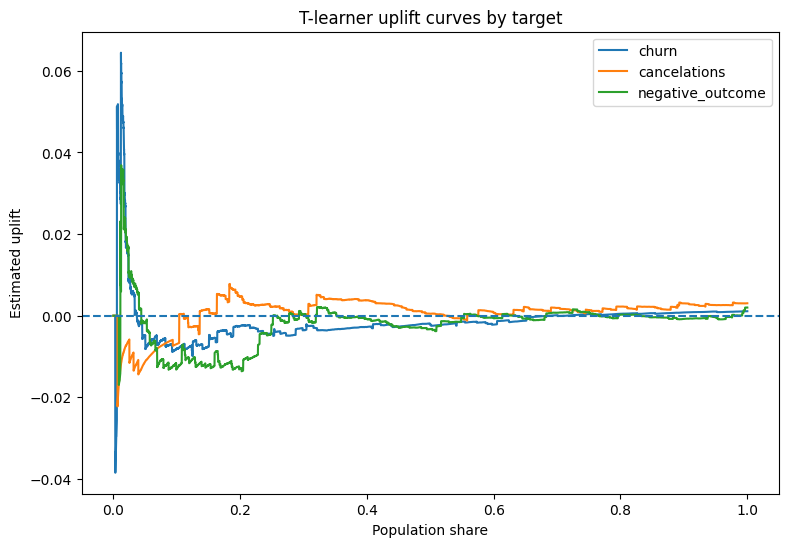

,positive_rate,mean_predicted_uplift,max_curve,min_curve
cancelations,0.010894,-0.142541,0.007787,-0.022222
negative_outcome,0.017009,-0.126627,0.036859,-0.016949
churn,0.006782,-0.082950,0.064423,-0.038462


In [677]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

targets = {
    "churn": "churn",
    "cancelations": "cancelations",
    "negative_outcome": "negative_outcome"
}

t = df_model["treatment"]

def qini_curve(uplift, y, t):
    df_qini = pd.DataFrame({"uplift": uplift, "y": y, "t": t})
    df_qini = df_qini.sort_values("uplift", ascending=True)

    df_qini["cum_t"] = (df_qini["t"] == 1).cumsum()
    df_qini["cum_c"] = (df_qini["t"] == 0).cumsum()

    df_qini["cum_y_t"] = ((df_qini["t"] == 1) & (df_qini["y"] == 1)).cumsum()
    df_qini["cum_y_c"] = ((df_qini["t"] == 0) & (df_qini["y"] == 1)).cumsum()

    rate_t = df_qini["cum_y_t"] / df_qini["cum_t"].replace(0, np.nan)
    rate_c = df_qini["cum_y_c"] / df_qini["cum_c"].replace(0, np.nan)

    return np.linspace(0, 1, len(df_qini)), rate_c - rate_t

plt.figure(figsize=(9, 6))
results = {}

for name, target_col in targets.items():
    y = df_model[target_col]

    # split data for this target
    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t,
        test_size=0.3,
        random_state=42,
        stratify=t
    )

    # train T-learner
    model_t = RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        class_weight="balanced",
        random_state=42
    )

    model_c = RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        class_weight="balanced",
        random_state=42
    )

    model_t.fit(X_train[t_train == 1], y_train[t_train == 1])
    model_c.fit(X_train[t_train == 0], y_train[t_train == 0])

    # probability of negative outcome with / without treatment
    p_t = model_t.predict_proba(X_test)[:, 1]
    p_c = model_c.predict_proba(X_test)[:, 1]

    # positive value = treatment reduces negative outcome
    uplift = p_c - p_t

    x_curve, y_curve = qini_curve(uplift, y_test.values, t_test.values)

    plt.plot(x_curve, y_curve, label=name)

    results[name] = {
        "positive_rate": y.mean(),
        "mean_predicted_uplift": uplift.mean(),
        "max_curve": np.nanmax(y_curve),
        "min_curve": np.nanmin(y_curve)
    }

plt.axhline(0, linestyle="--")
plt.xlabel("Population share")
plt.ylabel("Estimated uplift")
plt.title("T-learner uplift curves by target")
plt.legend()
plt.show()

pd.DataFrame(results).T.sort_values("max_curve", ascending=True)

### Uplift Models Comparison

Comparison of T-learner and Causal Forest using uplift and Qini curves.

- Uplift curve: difference between control and treatment outcomes (sorted by predicted uplift, sleeping dogs first).
- Qini curve: model performance vs random targeting.
- Qini score: area above the random baseline.


=== TARGET: cancelations ===


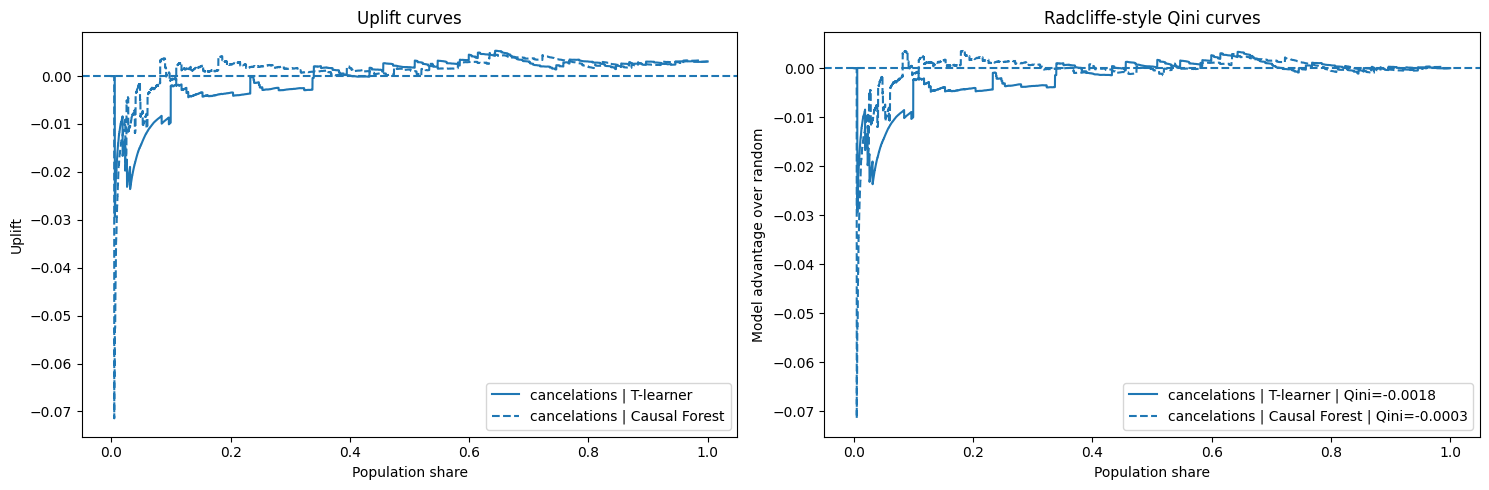

ATE_like_final_effect  Radcliffe_Qini  max_curve  \
cancelations T-learner                   0.003047       -0.001829   0.005292   
             Causal Forest               0.003047       -0.000304   0.004837   

                            min_curve  mean_predicted_uplift  
cancelations T-learner      -0.029412              -0.103191  
             Causal Forest  -0.071429              -0.000087

In [678]:
# Required libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from econml.dml import CausalForestDML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Target variable(s)
targets_selected = {
    "cancelations": "cancelations",
}

# Treatment indicator
t = df_model["treatment"]


def uplift_curve_data(uplift, y, t, ascending=True):
    # Rank observations by predicted uplift
    df_qini = pd.DataFrame({"uplift": uplift, "y": y, "t": t})
    df_qini = df_qini.sort_values("uplift", ascending=ascending)

    # Cumulative treatment/control counts
    df_qini["cum_t"] = (df_qini["t"] == 1).cumsum()
    df_qini["cum_c"] = (df_qini["t"] == 0).cumsum()

    # Cumulative positive outcomes in each group
    df_qini["cum_y_t"] = ((df_qini["t"] == 1) & (df_qini["y"] == 1)).cumsum()
    df_qini["cum_y_c"] = ((df_qini["t"] == 0) & (df_qini["y"] == 1)).cumsum()

    # Running outcome rates
    rate_t = df_qini["cum_y_t"] / df_qini["cum_t"].replace(0, np.nan)
    rate_c = df_qini["cum_y_c"] / df_qini["cum_c"].replace(0, np.nan)

    # Positive uplift means treatment reduces the negative outcome
    curve = (rate_c - rate_t).fillna(0)
    x = np.linspace(0, 1, len(df_qini))

    return x, curve


def radcliffe_qini(x, curve):
    # Random targeting baseline from 0 to final effect
    baseline = np.linspace(0, curve.iloc[-1], len(curve))

    # Difference between model curve and random baseline
    qini_curve = curve - baseline

    # Area under the Qini curve
    qini_score = np.trapezoid(qini_curve, x)

    return baseline, qini_curve, qini_score


# Prepare plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

results = {}
colors = plt.cm.tab10(np.linspace(0, 1, len(targets_selected)))

for (name, target_col), color in zip(targets_selected.items(), colors):
    print(f"\n=== TARGET: {name} ===")

    y = df_model[target_col]

    # Train/test split with treatment stratification
    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t,
        test_size=0.3,
        random_state=42,
        stratify=t
    )

    # ---------------------------
    # T-learner
    # ---------------------------

    # Model trained on treated observations
    model_t = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    # Model trained on control observations
    model_c = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    # Fit separate models for treatment and control groups
    model_t.fit(X_train[t_train == 1], y_train[t_train == 1])
    model_c.fit(X_train[t_train == 0], y_train[t_train == 0])

    # Predict outcome probabilities under treatment/control
    p_t = model_t.predict_proba(X_test)[:, 1]
    p_c = model_c.predict_proba(X_test)[:, 1]

    # Positive value = expected reduction in cancelations
    uplift_tlearner = p_c - p_t

    # ---------------------------
    # Causal Forest
    # ---------------------------

    # Causal forest estimates heterogeneous treatment effects
    cf = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=500,
            max_depth=4,
            random_state=42
        ),
        model_t=RandomForestClassifier(
            n_estimators=500,
            max_depth=4,
            class_weight="balanced",
            random_state=42
        ),
        discrete_treatment=True,
        random_state=42
    )

    # Fit causal forest on training data
    cf.fit(y_train, t_train, X=X_train)

    # Effect is multiplied by -1:
    # positive value = treatment reduces cancelations
    uplift_cf = -cf.effect(X_test)

    # ---------------------------
    # Curves and Qini
    # ---------------------------

    for model_name, uplift, linestyle in [
        ("T-learner", uplift_tlearner, "-"),
        ("Causal Forest", uplift_cf, "--")
    ]:
        # Build uplift curve
        x, curve = uplift_curve_data(
            uplift,
            y_test.values,
            t_test.values,
            ascending=True
        )

        # Compute Radcliffe-style Qini curve and score
        baseline, qini_curve, qini_score = radcliffe_qini(x, curve)

        # Plot raw uplift curve
        axes[0].plot(
            x, curve,
            color=color,
            linestyle=linestyle,
            label=f"{name} | {model_name}"
        )

        # Plot model advantage over random targeting
        axes[1].plot(
            x, qini_curve,
            color=color,
            linestyle=linestyle,
            label=f"{name} | {model_name} | Qini={qini_score:.4f}"
        )

        # Store summary metrics
        results[(name, model_name)] = {
            "ATE_like_final_effect": curve.iloc[-1],
            "Radcliffe_Qini": qini_score,
            "max_curve": curve.max(),
            "min_curve": curve.min(),
            "mean_predicted_uplift": np.mean(uplift)
        }

# Format uplift curve plot
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Uplift curves")
axes[0].set_xlabel("Population share")
axes[0].set_ylabel("Uplift")
axes[0].legend()

# Format Qini plot
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Radcliffe-style Qini curves")
axes[1].set_xlabel("Population share")
axes[1].set_ylabel("Model advantage over random")
axes[1].legend()

plt.tight_layout()
plt.show()

# Show result table
pd.DataFrame(results).T.sort_values("Radcliffe_Qini", ascending=True)

### Segment-Level Uplift Analysis (T-Learner)

To better understand how treatment effects vary across the population, customers are ranked by predicted uplift and divided into non-overlapping segments. 

For each segment, we compare the observed outcome rates between treatment and control groups. This allows us to identify regions with negative, neutral, or positive treatment effects without relying on cumulative aggregation.

In [679]:
# ============================
# Segment-level uplift analysis (non-cumulative)
# ============================

# create dataframe with predictions and outcomes
tmp = pd.DataFrame({
    "uplift": uplift_tlearner,   # predicted uplift from T-learner
    "y": y_test.values,          # observed outcome (e.g., cancelation)
    "t": t_test.values           # treatment indicator
}).sort_values("uplift", ascending=True).reset_index(drop=True)
# sort by uplift: worst (negative effect) first

n = len(tmp)

# define segment boundaries (shares of population)
cuts = [0.10, 0.25, 0.60, 1.00]

rows = []
start = 0

for c in cuts:
    end = int(n * c)

    # select non-overlapping segment
    g = tmp.iloc[start:end]

    # split into treatment and control
    g_t = g[g["t"] == 1]["y"]
    g_c = g[g["t"] == 0]["y"]

    # compute observed outcome rates
    rate_t = g_t.mean()
    rate_c = g_c.mean()

    # store segment statistics
    rows.append({
        "range": f"{start/n:.1%}–{end/n:.1%}",
        "n_total": len(g),

        "n_treatment": len(g_t),
        "n_control": len(g_c),

        "cancel_treatment": int(g_t.sum()),
        "cancel_control": int(g_c.sum()),

        "rate_t": rate_t,
        "rate_c": rate_c,

        # uplift definition: difference between control and treatment
        "segment_uplift_emp": rate_c - rate_t
    })

    # move to next segment
    start = end

# final table
result = pd.DataFrame(rows)
result

,range,n_total,n_treatment,n_control,cancel_treatment,cancel_control,rate_t,rate_c,segment_uplift_emp
0,0.0%–10.0%,853,722,131,7,1,0.009695,0.007634,-0.002062
1,10.0%–25.0%,1281,1101,180,9,1,0.008174,0.005556,-0.002619
2,25.0%–60.0%,2988,2460,528,16,8,0.006504,0.015152,0.008647
3,60.0%–100.0%,3415,2706,709,37,10,0.013673,0.014104,0.000431


### Placebo Test for T-Learner

As a sanity check, treatment assignment is randomly shuffled to remove any true causal signal. The T-learner is then applied to this randomized setup. If the model is correctly specified, the resulting uplift curves should be close to zero, indicating no spurious patterns are learned.

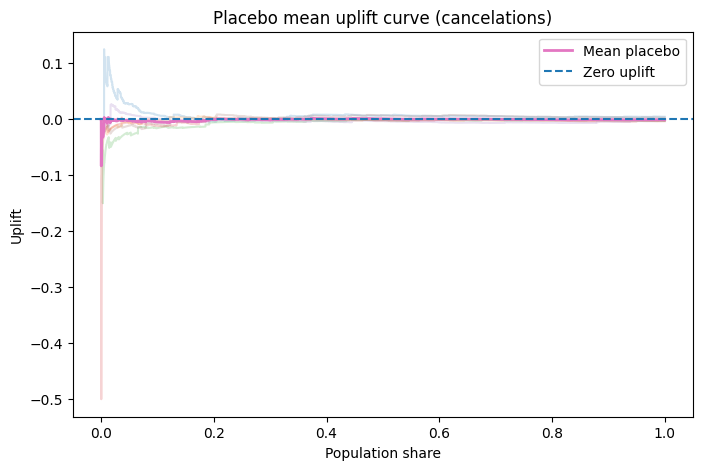

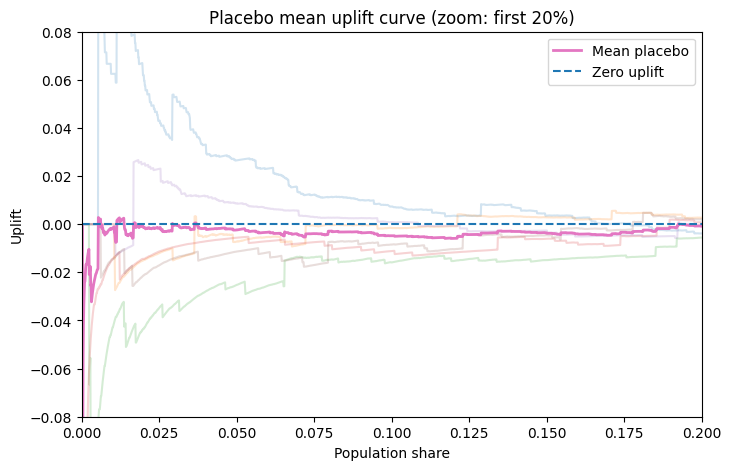

In [680]:
# ============================
# PLACEBO TEST: MEAN UPLIFT CURVE
# Target: cancelations
# ============================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# outcome and treatment
y = df_model["cancelations"].astype(int)
t = df_model["treatment"].astype(int)

# keep only valid observations
valid = y.notna() & t.notna()
X_use = X.loc[valid].reset_index(drop=True)
y_use = y.loc[valid].reset_index(drop=True)
t_use = t.loc[valid].reset_index(drop=True)


def uplift_curve(uplift, y, t):
    """
    Build uplift curve by sorting customers from lowest to highest predicted uplift.
    Since the focus is on sleeping dogs, negative uplift is shown first.
    """
    df_qini = pd.DataFrame({
        "uplift": uplift,
        "y": y,
        "t": t
    }).sort_values("uplift", ascending=True)

    # cumulative treatment/control counts
    df_qini["cum_t"] = (df_qini["t"] == 1).cumsum()
    df_qini["cum_c"] = (df_qini["t"] == 0).cumsum()

    # cumulative outcome counts in treatment/control groups
    df_qini["cum_y_t"] = ((df_qini["t"] == 1) & (df_qini["y"] == 1)).cumsum()
    df_qini["cum_y_c"] = ((df_qini["t"] == 0) & (df_qini["y"] == 1)).cumsum()

    # observed cumulative outcome rates
    rate_t = df_qini["cum_y_t"] / df_qini["cum_t"].replace(0, np.nan)
    rate_c = df_qini["cum_y_c"] / df_qini["cum_c"].replace(0, np.nan)

    # uplift definition: positive = treatment reduces cancelations
    curve = (rate_c - rate_t).fillna(0)

    x = np.linspace(0, 1, len(df_qini))
    return x, curve


# multiple seeds reduce dependence on one random split
seeds = [2, 3, 26, 42, 66, 78]
curves = []

plt.figure(figsize=(8, 5))

for rs in seeds:

    # randomly shuffle treatment assignment
    # this destroys the real causal link between treatment and outcome
    t_placebo = t_use.sample(frac=1, random_state=rs).reset_index(drop=True)

    # split data using placebo treatment
    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X_use,
        y_use,
        t_placebo,
        test_size=0.3,
        random_state=rs,
        stratify=t_placebo
    )

    # T-learner: model for placebo treatment group
    model_t = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=5,
        max_features="sqrt"
    )

    # T-learner: model for placebo control group
    model_c = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=5,
        max_features="sqrt"
    )

    # fit separate outcome models
    model_t.fit(X_train[t_train == 1], y_train[t_train == 1])
    model_c.fit(X_train[t_train == 0], y_train[t_train == 0])

    # predicted cancelation probabilities under placebo treatment/control
    p_t = model_t.predict_proba(X_test)[:, 1]
    p_c = model_c.predict_proba(X_test)[:, 1]

    # placebo uplift should be close to zero
    uplift_placebo = p_c - p_t

    # build placebo uplift curve
    x, curve = uplift_curve(uplift_placebo, y_test.values, t_test.values)
    curves.append(curve.values)

    # plot individual seed curves lightly
    plt.plot(x, curve, alpha=0.2)

# average placebo curve across seeds
mean_curve = np.mean(curves, axis=0)

plt.plot(x, mean_curve, linewidth=2, label="Mean placebo")
plt.axhline(0, linestyle="--", label="Zero uplift")

plt.title("Placebo mean uplift curve (cancelations)")
plt.xlabel("Population share")
plt.ylabel("Uplift")
plt.legend()
plt.show()

# ============================
# Zoom: first 20% of population
# ============================

plt.figure(figsize=(8, 5))

for curve in curves:
    plt.plot(x, curve, alpha=0.2)

plt.plot(x, mean_curve, linewidth=2, label="Mean placebo")
plt.axhline(0, linestyle="--", label="Zero uplift")

plt.xlim(0, 0.20)
plt.ylim(-0.08, 0.08)

plt.title("Placebo mean uplift curve (zoom: first 20%)")
plt.xlabel("Population share")
plt.ylabel("Uplift")
plt.legend()
plt.show()

### T-Learner Stability Across Random Seeds

To assess the robustness of the uplift estimates, the T-learner is trained across multiple random train-test splits. The resulting uplift curves are averaged to reduce variance caused by sampling noise, which is particularly important given the rarity of the outcome.

In [681]:
print(len(seeds))
print(seeds[:10])

6
[2, 3, 26, 42, 66, 78]


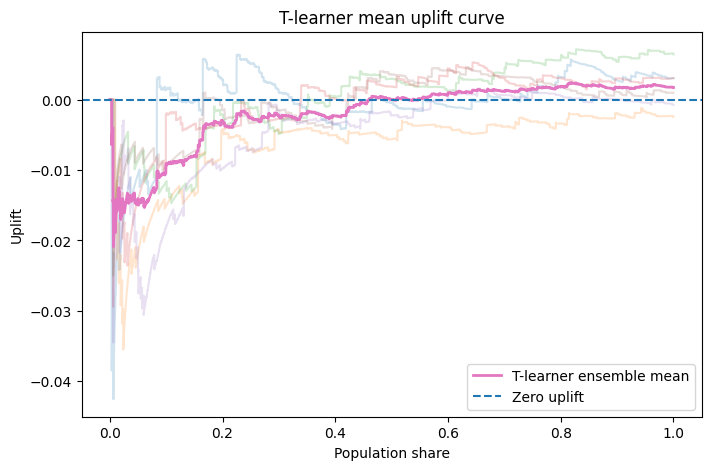

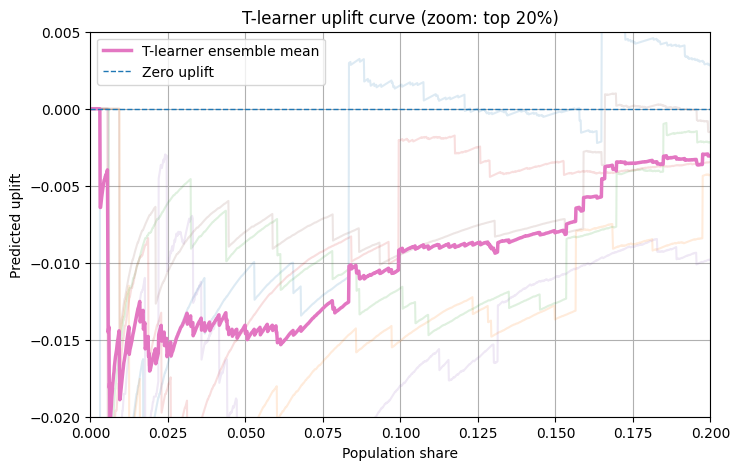

Saved: ..\models\t_learner_ensemble.joblib
Number of models: 6 6


,n_total,n_treatment,n_control,cancel_treatment_emp_mean,cancel_control_emp_mean,rate_t_emp_mean,rate_c_emp_mean,segment_uplift_emp_mean,segment_uplift_pred_mean
range,,,,,,,,,
0.0%–10.0%,853.0,711.166667,141.833333,9.166667,0.500000,0.013129,0.003987,-0.009141,-0.237680
10.0%–25.0%,1281.0,1081.166667,199.833333,10.166667,2.166667,0.009417,0.010916,0.001499,-0.176740
25.0%–60.0%,2988.0,2474.166667,513.833333,21.833333,6.333333,0.008813,0.012281,0.003468,-0.119851
60.0%–100.0%,3415.0,2722.500000,692.500000,31.166667,9.666667,0.011446,0.014211,0.002765,-0.026430


In [682]:
# ============================
# T-learner ensemble training + stability analysis
# ============================

import joblib
from pathlib import Path

curves = []
all_rows = []

models_t = []
models_c = []

plt.figure(figsize=(8, 5))

for rs in seeds:

    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t,
        test_size=0.3,
        random_state=rs,
        stratify=t
    )

    model_t = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    model_c = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    model_t.fit(X_train[t_train == 1], y_train[t_train == 1])
    model_c.fit(X_train[t_train == 0], y_train[t_train == 0])

    models_t.append(model_t)
    models_c.append(model_c)

    p_t = model_t.predict_proba(X_test)[:, 1]
    p_c = model_c.predict_proba(X_test)[:, 1]

    uplift = p_c - p_t

    x, curve = uplift_curve(uplift, y_test.values, t_test.values)
    curves.append(curve.values)

    plt.plot(x, curve, alpha=0.2)

    tmp = pd.DataFrame({
        "uplift": uplift,
        "y": y_test.values,
        "t": t_test.values
    }).sort_values("uplift", ascending=True).reset_index(drop=True)

    n = len(tmp)
    start = 0

    for c in cuts:
        end = int(n * c)
        g = tmp.iloc[start:end]

        g_t = g[g["t"] == 1]["y"]
        g_c = g[g["t"] == 0]["y"]

        all_rows.append({
            "seed": rs,
            "range": f"{start/n:.1%}–{end/n:.1%}",
            "n_total": len(g),
            "n_treatment": len(g_t),
            "n_control": len(g_c),
            "cancel_treatment_emp_mean": int(g_t.sum()),
            "cancel_control_emp_mean": int(g_c.sum()),
            "rate_t_emp_mean": g_t.mean(),
            "rate_c_emp_mean": g_c.mean(),
            "segment_uplift_emp_mean": g_c.mean() - g_t.mean(),
            "segment_uplift_pred_mean": g["uplift"].mean()
        })

        start = end

segment_results = pd.DataFrame(all_rows)

segment_summary = (
    segment_results
    .groupby("range")
    .mean(numeric_only=True)
    .drop(columns=["seed"])
)

mean_curve = np.mean(curves, axis=0)

plt.plot(x, mean_curve, linewidth=2, label="T-learner ensemble mean")
plt.axhline(0, linestyle="--", label="Zero uplift")
plt.title("T-learner mean uplift curve")
plt.xlabel("Population share")
plt.ylabel("Uplift")
plt.legend()
plt.show()

# save ensemble
model_path = Path("../models")
model_path.mkdir(exist_ok=True)

joblib.dump(
    {
        "models_t": models_t,
        "models_c": models_c,
        "feature_columns": X.columns.tolist(),
        "seeds": seeds,
    },
    model_path / "t_learner_ensemble.joblib"
)

# ============================
# Zoom: top 20% of population
# ============================

plt.figure(figsize=(8, 5))

# individual seed curves
for curve in curves:
    plt.plot(x, curve, alpha=0.15)

# ensemble mean
plt.plot(
    x,
    mean_curve,
    linewidth=2.5,
    label="T-learner ensemble mean"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
    label="Zero uplift"
)

# zoom
plt.xlim(0, 0.20)
plt.ylim(-0.02, 0.005)

plt.title("T-learner uplift curve (zoom: top 20%)")
plt.xlabel("Population share")
plt.ylabel("Predicted uplift")

plt.legend()
plt.grid(True)

plt.show()

print("Saved:", model_path / "t_learner_ensemble.joblib")
print("Number of models:", len(models_t), len(models_c))

segment_summary

In [683]:
# ============================
# Mean feature importance across seeds
# ============================

importances_t = []
importances_c = []

for rs in seeds:

    # split data
    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t,
        test_size=0.3,
        random_state=rs,
        stratify=t
    )

    # treatment model
    model_t = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    # control model
    model_c = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    # fit models
    model_t.fit(X_train[t_train == 1], y_train[t_train == 1])
    model_c.fit(X_train[t_train == 0], y_train[t_train == 0])

    # store feature importances
    importances_t.append(model_t.feature_importances_)
    importances_c.append(model_c.feature_importances_)

# mean feature importance across seeds
feature_importance_t_mean = pd.Series(
    np.mean(importances_t, axis=0),
    index=X.columns
).sort_values(ascending=False)

feature_importance_c_mean = pd.Series(
    np.mean(importances_c, axis=0),
    index=X.columns
).sort_values(ascending=False)

# report
print("=== Treatment model ===")
print(feature_importance_t_mean.head(20))

print("\n=== Control model ===")
print(feature_importance_c_mean.head(20))

=== Treatment model ===
current_tenure            0.201068
total_tenure              0.140899
tenure_years              0.137643
tenure_ratio              0.120284
payment_method_SEPA       0.039075
cluster_Elefant           0.033469
payment_method_Invoice    0.029993
age_bin__65_75_           0.027073
milieu_PMA                0.021959
age_bin__40_55_           0.021124
cluster_Floh              0.020703
gender_male               0.018700
cluster_Kroete            0.016535
cluster_Seehund           0.013277
milieu_KOG                0.012745
has_phone                 0.012140
age_bin_unknown           0.011141
milieu_NOB                0.010653
milieu_PER                0.010500
billing_freq_M            0.010389
dtype: float64

=== Control model ===
current_tenure         0.182766
total_tenure           0.153696
tenure_years           0.127742
tenure_ratio           0.105051
cluster_Elefant        0.040434
milieu_PMA             0.033170
milieu_TRA             0.032766
age_bin__65_75

### Causal Forest stability across random seeds

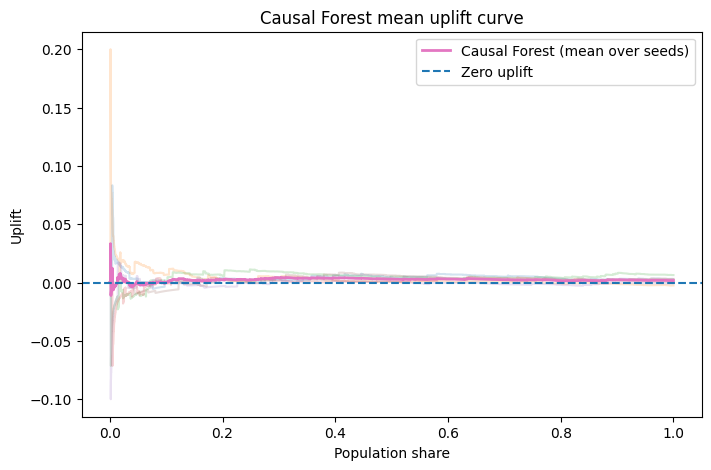

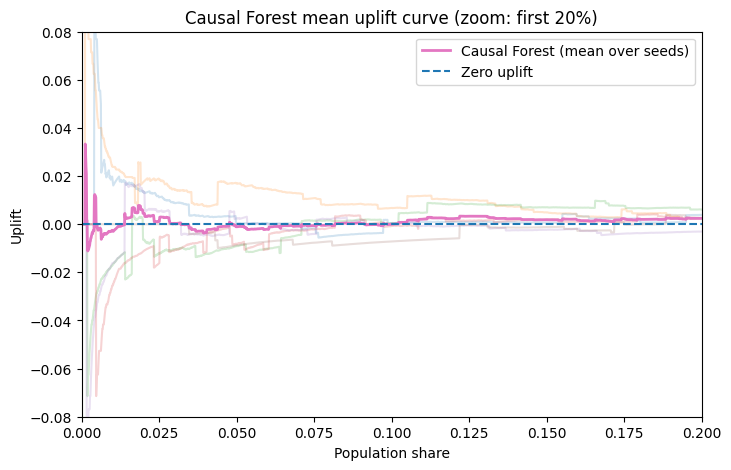

,n_total,n_treatment,n_control,cancel_treatment_emp_mean,cancel_control_emp_mean,rate_t_emp_mean,rate_c_emp_mean,segment_uplift_emp_mean,segment_uplift_pred_mean
range,,,,,,,,,
0.0%–10.0%,853.0,655.000000,198.000000,7.833333,2.500000,0.012079,0.012047,-0.000032,-0.034644
10.0%–25.0%,1281.0,1067.666667,213.333333,9.000000,2.666667,0.008413,0.012349,0.003937,-0.014976
25.0%–60.0%,2988.0,2603.666667,384.333333,25.166667,5.000000,0.009666,0.012827,0.003161,-0.005317
60.0%–100.0%,3415.0,2662.666667,752.333333,30.333333,8.500000,0.011407,0.011375,-0.000032,0.019050


In [684]:
# ============================
# Causal Forest stability analysis + segment-level evaluation
# ============================

curves_cf = []
all_rows_cf = []

plt.figure(figsize=(8, 5))

for rs in seeds:

    # split data
    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t,
        test_size=0.3,
        random_state=rs,
        stratify=t
    )

    # Causal Forest
    cf = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=500,
            max_depth=4,
            random_state=rs
        ),
        model_t=RandomForestClassifier(
            n_estimators=500,
            max_depth=4,
            class_weight="balanced",
            random_state=rs
        ),
        discrete_treatment=True,
        random_state=rs
    )

    cf.fit(y_train, t_train, X=X_train)

    # effect on negative outcome
    # multiply by -1 so positive = treatment reduces cancelations
    uplift = -cf.effect(X_test)

    # build uplift curve
    x, curve = uplift_curve(uplift, y_test.values, t_test.values)
    curves_cf.append(curve.values)

    # plot individual seed curves lightly
    plt.plot(x, curve, alpha=0.2)

    # ============================
    # Segment-level analysis
    # ============================

    tmp = pd.DataFrame({
        "uplift": uplift,
        "y": y_test.values,
        "t": t_test.values
    }).sort_values("uplift", ascending=True).reset_index(drop=True)

    n = len(tmp)
    start = 0

    for c in cuts:
        end = int(n * c)
        g = tmp.iloc[start:end]

        g_t = g[g["t"] == 1]["y"]
        g_c = g[g["t"] == 0]["y"]
        g_uplift = g["uplift"]

        all_rows_cf.append({
            "seed": rs,
            "range": f"{start/n:.1%}–{end/n:.1%}",
            "n_total": len(g),
            "n_treatment": len(g_t),
            "n_control": len(g_c),
            "cancel_treatment_emp_mean": int(g_t.sum()),
            "cancel_control_emp_mean": int(g_c.sum()),
            "rate_t_emp_mean": g_t.mean(),
            "rate_c_emp_mean": g_c.mean(),
            "segment_uplift_emp_mean": g_c.mean() - g_t.mean(),
            "segment_uplift_pred_mean": g_uplift.mean()
        })

        start = end

# combine all seeds
segment_results_cf = pd.DataFrame(all_rows_cf)

segment_summary_cf = (
    segment_results_cf
    .groupby("range")
    .mean(numeric_only=True)
    .drop(columns=["seed"])
)

# ============================
# Mean uplift curve
# ============================

mean_curve_cf = np.mean(curves_cf, axis=0)

plt.plot(
    x,
    mean_curve_cf,
    linewidth=2,
    label="Causal Forest (mean over seeds)"
)

plt.axhline(0, linestyle="--", label="Zero uplift")

plt.title("Causal Forest mean uplift curve")
plt.xlabel("Population share")
plt.ylabel("Uplift")
plt.legend()
plt.show()

# ============================
# Zoom: first 20% of population
# ============================

plt.figure(figsize=(8, 5))

# plot individual seed curves
for curve in curves_cf:
    plt.plot(x, curve, alpha=0.2)

# plot mean curve
plt.plot(
    x,
    mean_curve_cf,
    linewidth=2,
    label="Causal Forest (mean over seeds)"
)

plt.axhline(0, linestyle="--", label="Zero uplift")

plt.xlim(0, 0.20)
plt.ylim(-0.08, 0.08)

plt.title("Causal Forest mean uplift curve (zoom: first 20%)")
plt.xlabel("Population share")
plt.ylabel("Uplift")
plt.legend()
plt.show()

segment_summary_cf

In [685]:
# T-learner feature importance

feature_importance_t = pd.Series(
    model_t.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance_c = pd.Series(
    model_c.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("=== Treatment model ===")
print(feature_importance_t.head(20))

print("\n=== Control model ===")
print(feature_importance_c.head(20))

=== Treatment model ===
current_tenure            0.180303
tenure_years              0.141230
total_tenure              0.139123
tenure_ratio              0.109747
cluster_Elefant           0.036750
cluster_Kroete            0.035717
cluster_Floh              0.031111
age_bin__40_55_           0.029596
milieu_PER                0.025447
payment_method_SEPA       0.024803
milieu_PMA                0.024310
age_bin_unknown           0.021094
age_bin__65_75_           0.020572
payment_method_Invoice    0.019176
milieu_KOG                0.016185
has_phone                 0.015946
gender_male               0.015368
cluster_Seehund           0.012247
milieu_TRA                0.011296
age_bin__55_65_           0.010955
dtype: float64

=== Control model ===
current_tenure      0.172276
total_tenure        0.133142
tenure_ratio        0.114660
tenure_years        0.103601
milieu_PMA          0.057477
milieu_TRA          0.050065
milieu_KOG          0.029747
cluster_Elefant     0.026197
age_bi

### Relative Qini Curve (sleeping dogs)

Customers are sorted from most harmful to least (ascending uplift).

- Curve shows cumulative effect of treatment  
- Down = treatment reduces cancelations (good)  
- Up = treatment increases cancelations (bad)

Dashed line = random targeting (ATE adjusted)

Higher than baseline → model finds sleeping dogs better than random

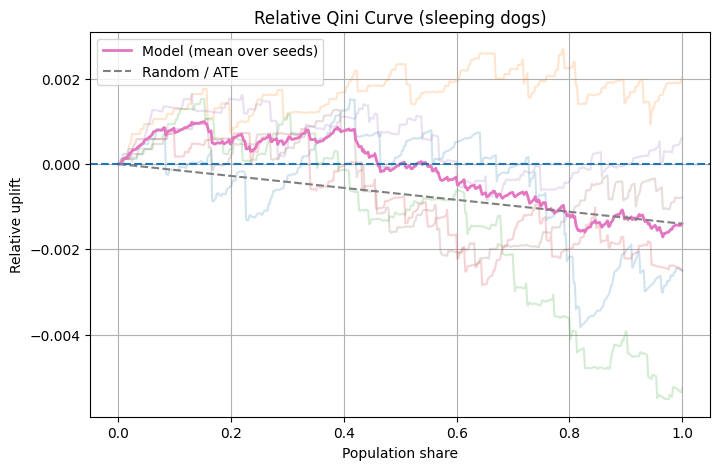

In [686]:
# ============================
# Relative Qini Curve (sleeping dogs, mean over seeds)
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

seeds = [2, 3, 26, 42, 66, 78]

curves = []
baselines = []
x_grid = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 5))

for rs in seeds:

    # split
    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t,
        test_size=0.3,
        random_state=rs,
        stratify=t
    )

    # T-learner
    model_t = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    model_c = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    model_t.fit(X_train[t_train == 1], y_train[t_train == 1])
    model_c.fit(X_train[t_train == 0], y_train[t_train == 0])

    uplift = (
        model_c.predict_proba(X_test)[:, 1]
        - model_t.predict_proba(X_test)[:, 1]
    )

    # build df
    df_qini = pd.DataFrame({
        "uplift": uplift,
        "y": y_test.values,
        "t": t_test.values
    }).sort_values("uplift", ascending=True).reset_index(drop=True)

    # cumulative
    df_qini["cum_n"] = np.arange(1, len(df_qini) + 1)
    df_qini["share"] = df_qini["cum_n"] / len(df_qini)

    df_qini["cum_t"] = (df_qini["t"] == 1).cumsum()
    df_qini["cum_c"] = (df_qini["t"] == 0).cumsum()

    df_qini["cum_y_t"] = ((df_qini["t"] == 1) & (df_qini["y"] == 1)).cumsum()
    df_qini["cum_y_c"] = ((df_qini["t"] == 0) & (df_qini["y"] == 1)).cumsum()

    df_qini = df_qini[
        (df_qini["cum_t"] > 0) & (df_qini["cum_c"] > 0)
    ].copy()

    # expected
    df_qini["expected_ctrl"] = (
        df_qini["cum_t"] * df_qini["cum_y_c"] / df_qini["cum_c"]
    )

    # uplift gain (down = good)
    df_qini["uplift_gain"] = (
        df_qini["cum_y_t"] - df_qini["expected_ctrl"]
    )

    df_qini["uplift_rel"] = df_qini["uplift_gain"] / len(df_qini)

    # ---- FIXED BASELINE ----
    ate = (
    y_test[t_test == 1].mean()
    - y_test[t_test == 0].mean()
    )

    t_share = (t_test == 1).mean()

    df_qini["baseline"] = df_qini["share"] * ate * t_share

    # interpolate → smooth mean
    curve_interp = np.interp(x_grid, df_qini["share"], df_qini["uplift_rel"])
    base_interp = np.interp(x_grid, df_qini["share"], df_qini["baseline"])

    curves.append(curve_interp)
    baselines.append(base_interp)

    plt.plot(x_grid, curve_interp, alpha=0.2)

# mean curves
mean_curve = np.mean(curves, axis=0)
mean_base = np.mean(baselines, axis=0)

plt.plot(x_grid, mean_curve, linewidth=2, label="Model (mean over seeds)")
plt.plot(x_grid, mean_base, linestyle="--", label="Random / ATE")

plt.axhline(0, linestyle="--")

plt.xlabel("Population share")
plt.ylabel("Relative uplift")
plt.title("Relative Qini Curve (sleeping dogs)")
plt.legend()
plt.grid(True)
plt.show()

### Qini Curve for Persuadables

Customers are sorted from highest to lowest predicted uplift.

- Focus: customers who benefit most from the email
- Curve shows prevented cancelations
- Higher values = better targeting
- Dashed line = random targeting baseline

If the model curve is above the baseline, the model performs better than random selection.

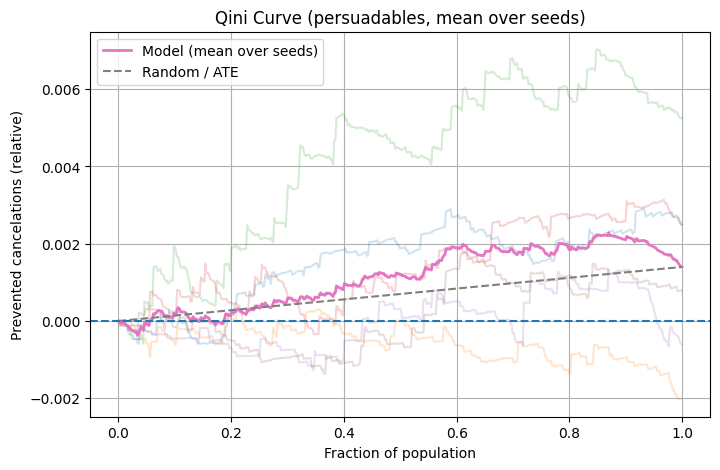

In [687]:
# ============================
# Qini Curve (persuadables, mean over seeds)
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

qini_curves = []          # store interpolated Qini curves for each seed
baseline_curves = []      # store interpolated random/ATE baselines
x_grid = np.linspace(0, 1, 500)  # common x-axis for averaging curves

plt.figure(figsize=(8, 5))

for rs in seeds:

    # split data (stratified by treatment to keep proportions stable)
    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t,
        test_size=0.3,
        random_state=rs,
        stratify=t
    )

    # T-learner: model for treated population
    model_t = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    # T-learner: model for control population
    model_c = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    # fit separate models on treated and control groups
    model_t.fit(X_train[t_train == 1], y_train[t_train == 1])
    model_c.fit(X_train[t_train == 0], y_train[t_train == 0])

    # predicted probability of outcome under treatment vs control
    p_t = model_t.predict_proba(X_test)[:, 1]
    p_c = model_c.predict_proba(X_test)[:, 1]

    # uplift estimate: positive → treatment reduces cancelations
    uplift = p_c - p_t

    # build dataframe sorted by predicted uplift (descending = best first)
    df_qini = pd.DataFrame({
        "uplift": uplift,
        "y": y_test.values,
        "t": t_test.values
    }).sort_values("uplift", ascending=False).reset_index(drop=True)

    # cumulative population share
    df_qini["cum_n"] = np.arange(1, len(df_qini) + 1)
    df_qini["perc"] = df_qini["cum_n"] / len(df_qini)

    # cumulative number of treated and control observations
    df_qini["cum_treat"] = (df_qini["t"] == 1).cumsum()
    df_qini["cum_ctrl"] = (df_qini["t"] == 0).cumsum()

    # cumulative number of events (cancelations) in each group
    df_qini["cum_y_treat"] = ((df_qini["t"] == 1) & (df_qini["y"] == 1)).cumsum()
    df_qini["cum_y_ctrl"] = ((df_qini["t"] == 0) & (df_qini["y"] == 1)).cumsum()

    # keep only rows where both groups are present (avoid division by zero)
    df_qini = df_qini[
        (df_qini["cum_treat"] > 0) & (df_qini["cum_ctrl"] > 0)
    ].copy()

    # expected number of events in treated group if they behaved like control
    df_qini["expected_ctrl"] = (
        df_qini["cum_treat"] * df_qini["cum_y_ctrl"] / df_qini["cum_ctrl"]
    )

    # Qini gain: how many cancelations were prevented by targeting
    df_qini["qini_gain"] = (
        df_qini["expected_ctrl"] - df_qini["cum_y_treat"]
    )

    # normalize by test set size (for comparability across splits)
    df_qini["qini_rel"] = df_qini["qini_gain"] / len(X_test)

    # ATE: average treatment effect (difference in outcome rates)
    ate = (
        y_test[t_test == 0].mean()
        - y_test[t_test == 1].mean()
    )

    # share of treated users
    t_share = (t_test == 1).mean()

    # random targeting baseline (linear growth)
    df_qini["baseline"] = df_qini["perc"] * ate * t_share

    # interpolate curves onto common grid for averaging
    qini_interp = np.interp(x_grid, df_qini["perc"], df_qini["qini_rel"])
    base_interp = np.interp(x_grid, df_qini["perc"], df_qini["baseline"])

    qini_curves.append(qini_interp)
    baseline_curves.append(base_interp)

    # plot individual seed curves (light → variability)
    plt.plot(x_grid, qini_interp, alpha=0.2)

# average curves across seeds
mean_qini = np.mean(qini_curves, axis=0)
mean_baseline = np.mean(baseline_curves, axis=0)

# plot averaged model performance
plt.plot(x_grid, mean_qini, linewidth=2, label="Model (mean over seeds)")

# plot averaged random baseline
plt.plot(x_grid, mean_baseline, linestyle="--", label="Random / ATE")

# zero reference line
plt.axhline(0, linestyle="--")

plt.xlabel("Fraction of population")
plt.ylabel("Prevented cancelations (relative)")
plt.title("Qini Curve (persuadables, mean over seeds)")
plt.legend()
plt.grid(True)
plt.show()

### Sleeping Dogs Cutoff Selection

Customers are sorted from the most negative predicted uplift to the most positive.

- The curve shows the mean observed treatment effect within the cumulative segment: control − treatment
- Negative values → treatment increases cancelations in this segment
- Positive values → treatment reduces cancelations in this segment

The cutoff is selected as the first point where the cumulative segment effect becomes ≥ 0.  
Everything before this point is treated as the sleeping-dogs segment and should not be targeted.

Very small segments (<5%) are ignored because their estimates are unstable.

Raw zero-crossing cutoff: 19.00%
Selected sleeping-dogs cutoff: 17.00%


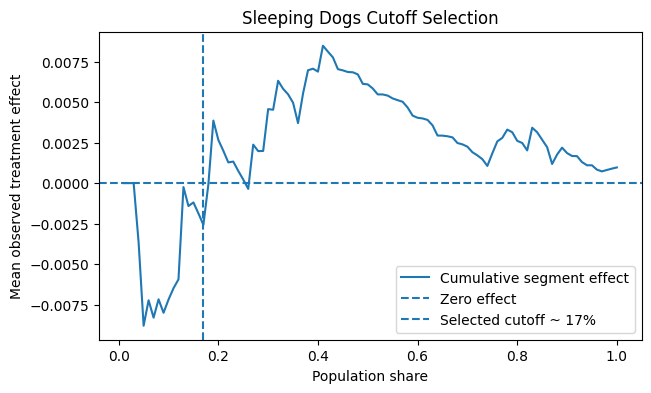

,share,n,rate_treatment,rate_control,cumulative_segment_effect
0,0.01,85,0.000000,0.000000,0.000000
1,0.02,170,0.000000,0.000000,0.000000
2,0.03,256,0.000000,0.000000,0.000000
3,0.04,341,0.003676,0.000000,-0.003676
4,0.05,426,0.008798,0.000000,-0.008798
5,0.06,512,0.007229,0.000000,-0.007229
6,0.07,597,0.008299,0.000000,-0.008299
7,0.08,682,0.007168,0.000000,-0.007168
8,0.09,768,0.008000,0.000000,-0.008000
9,0.10,853,0.007184,0.000000,-0.007184


In [688]:
# ============================
# Cutoff selection for sleeping dogs
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# tmp must already contain uplift, outcome, and treatment
# sorted from most negative predicted uplift to most positive
tmp = tmp.sort_values("uplift", ascending=True).reset_index(drop=True)

rows = []

for p in np.arange(0.01, 1.01, 0.01):
    end = int(len(tmp) * p)
    g = tmp.iloc[:end]  # cumulative segment: from 0% to p%

    # observed outcome rates in the cumulative segment
    g_t = g[g["t"] == 1]["y"]
    g_c = g[g["t"] == 0]["y"]

    if len(g_t) == 0 or len(g_c) == 0:
        continue

    rate_t = g_t.mean()
    rate_c = g_c.mean()

    rows.append({
        "share": p,
        "n": len(g),
        "rate_treatment": rate_t,
        "rate_control": rate_c,

        # mean observed treatment effect within the cumulative segment
        "cumulative_segment_effect": rate_c - rate_t
    })

cutoff_table = pd.DataFrame(rows)

# ignore very small segments, as they are highly unstable
valid = cutoff_table[cutoff_table["share"] >= 0.05]

# first point where the cumulative segment effect becomes non-negative
cutoff = valid[valid["cumulative_segment_effect"] >= 0].iloc[0]["share"]

# move slightly back to stay within the negative-effect region
final_cutoff = max(0.05, cutoff - 0.02)

print(f"Raw zero-crossing cutoff: {cutoff:.2%}")
print(f"Selected sleeping-dogs cutoff: {final_cutoff:.2%}")

plt.figure(figsize=(7, 4))
plt.plot(
    cutoff_table["share"],
    cutoff_table["cumulative_segment_effect"],
    label="Cumulative segment effect"
)

plt.axhline(0, linestyle="--", label="Zero effect")
plt.axvline(final_cutoff, linestyle="--", label=f"Selected cutoff ~ {final_cutoff:.0%}")

plt.xlabel("Population share")
plt.ylabel("Mean observed treatment effect")
plt.title("Sleeping Dogs Cutoff Selection")
plt.legend()
plt.show()

cutoff_table.head(20)

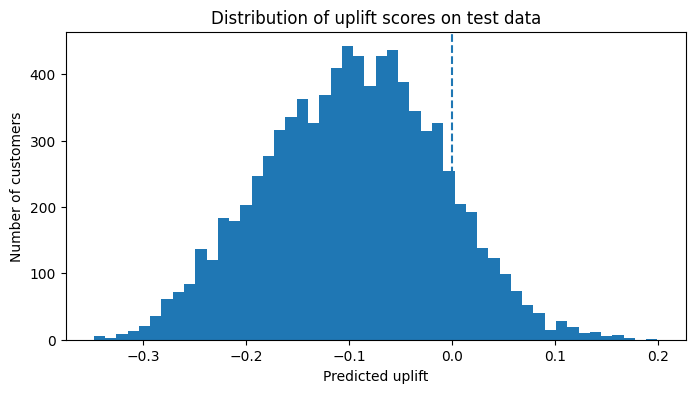

In [689]:
plt.figure(figsize=(8, 4))

plt.hist(uplift, bins=50)

plt.axvline(0, linestyle="--")

plt.xlabel("Predicted uplift")
plt.ylabel("Number of customers")

plt.title("Distribution of uplift scores on test data")

plt.show()

### Non-Cumulative Cutoff Check for Sleeping Dogs

Customers are sorted from most negative uplift to positive.

- Each 1% segment is evaluated separately
- Segment uplift = control cancelation rate − treatment cancelation rate
- Negative values → treatment increases cancelations
- Positive values → treatment reduces cancelations

This check validates whether the sleeping-dogs effect is visible locally, not only cumulatively.

Recommended cutoff: ~14%


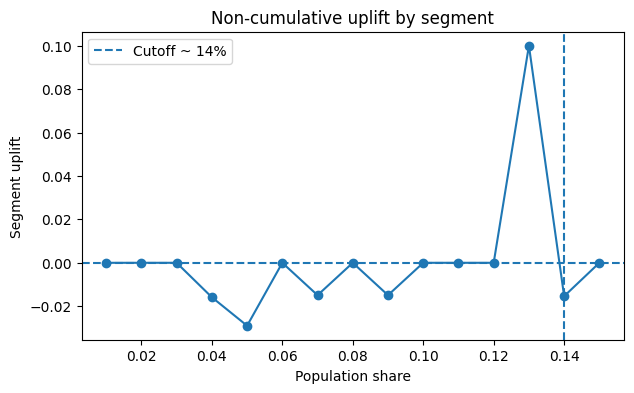

,range,start,end,n_total,n_treatment,n_control,cancel_treatment,cancel_control,rate_t,rate_c,cum_uplift_emp
0,0%–1%,0.00,0.01,85,62,23,0,0,0.000000,0.0,0.000000
1,1%–2%,0.01,0.02,85,75,10,0,0,0.000000,0.0,0.000000
2,2%–3%,0.02,0.03,86,72,14,0,0,0.000000,0.0,0.000000
3,3%–4%,0.03,0.04,85,63,22,1,0,0.015873,0.0,-0.015873
4,4%–5%,0.04,0.05,85,69,16,2,0,0.028986,0.0,-0.028986
5,5%–6%,0.05,0.06,86,74,12,0,0,0.000000,0.0,0.000000
6,6%–7%,0.06,0.07,85,67,18,1,0,0.014925,0.0,-0.014925
7,7%–8%,0.07,0.08,85,76,9,0,0,0.000000,0.0,0.000000
8,8%–9%,0.08,0.09,86,67,19,1,0,0.014925,0.0,-0.014925
9,9%–10%,0.09,0.10,85,71,14,0,0,0.000000,0.0,0.000000


In [690]:
# ============================
# Non-cumulative cutoff check for sleeping dogs
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sort customers by predicted uplift
# ascending=True → most negatively affected customers first
tmp = tmp.sort_values("uplift", ascending=True).reset_index(drop=True)

# Define small non-overlapping 1% segments up to 15%
bins = np.arange(0, 0.16, 0.01)

rows = []

for i in range(len(bins) - 1):
    start_p = bins[i]
    end_p = bins[i + 1]

    # Convert population shares into row indices
    start = int(len(tmp) * start_p)
    end = int(len(tmp) * end_p)

    # Select current non-cumulative segment
    g = tmp.iloc[start:end]

    # Split segment into treatment and control groups
    g_t = g[g["t"] == 1]["y"]
    g_c = g[g["t"] == 0]["y"]

    # Skip segment if one group is missing
    if len(g_t) == 0 or len(g_c) == 0:
        continue

    # Observed cancelation rates
    rate_t = g_t.mean()
    rate_c = g_c.mean()

    rows.append({
        "range": f"{start_p:.0%}–{end_p:.0%}",
        "start": start_p,
        "end": end_p,

        # Segment size
        "n_total": len(g),
        "n_treatment": len(g_t),
        "n_control": len(g_c),

        # Observed cancelation counts
        "cancel_treatment": int(g_t.sum()),
        "cancel_control": int(g_c.sum()),

        # Observed cancelation rates
        "rate_t": rate_t,
        "rate_c": rate_c,

        # Empirical segment uplift
        "cum_uplift_emp": rate_c - rate_t
    })

df_bins = pd.DataFrame(rows)

# Ignore very small early segments when selecting cutoff
valid = df_bins[df_bins["end"] >= 0.05]

# Find the last segment with negative empirical uplift
neg_bins = valid[valid["cum_uplift_emp"] < 0]

cutoff = neg_bins.iloc[-1]["end"] if len(neg_bins) > 0 else 0.05

print(f"Recommended cutoff: ~{cutoff:.0%}")

# Plot empirical uplift by local segment
plt.figure(figsize=(7, 4))
plt.plot(df_bins["end"], df_bins["cum_uplift_emp"], marker="o")
plt.axhline(0, linestyle="--")
plt.axvline(cutoff, linestyle="--", label=f"Cutoff ~ {cutoff:.0%}")

plt.xlabel("Population share")
plt.ylabel("Segment uplift")
plt.title("Non-cumulative uplift by segment")
plt.legend()
plt.show()

df_bins

# Model application

## Load new customer dataset for scoring

Load the new customer base (`test2.csv`) from the AB folder and standardize customer IDs to match the training data format.  
The dataset structure is checked afterwards to ensure compatibility with the existing feature engineering pipeline.

In [691]:
df_test2_raw = pd.read_csv(
    base_path / "AB" / "test2.csv",
    **read_kwargs
)

df_test2_raw["SAP GP Nummer"] = (
    df_test2_raw["SAP GP Nummer"]
    .astype("string")
    .str.strip()
    .str.zfill(10)
)

print(df_test2_raw.shape)
print(df_test2_raw.columns.tolist())
print(df_test2_raw.head())

(20689, 27)
['Accountname', 'SAP GP Nummer', 'E-Mail-Kontakt', 'letzter Abo - Auftrag: Auftrag von', 'letzter Abo - Auftrag: Auftrag bis', 'letzter Abo - Auftrag: Kündigungsgrund Code', 'Produkt / Abo-Status', 'letzter Abo - Auftrag: Fakturaperiodizität Code', 'letzter Abo - Auftrag: Zahlweg', 'letzter Abo - Auftrag: Bezugsgrund Code', 'letzter Abo - Auftrag: Werbeträger', 'Anrede', 'Geburtsdatum', 'Kundencluster Vertrieb', 'Sozialmilieu', 'Telefon privat', 'Telefon mobil', 'Haltbarkeit letzte Beziehung', 'Kumulierte Haltbarkeit', 'zuletzt aktiv Portal', 'zuletzt aktiv News App', 'zuletzt aktiv E-Paper Web', 'zuletzt aktiv E-Paper App', 'Nutzung E-Paper App', 'Nutzung E-Paper Web', 'Nutzung News App', 'Nutzung Portal']
           Accountname SAP GP Nummer E-Mail-Kontakt  \
0         Marion Lager    0002491157        SHZV-Ja   
1       Hans Holtgreve    0002107336        SHZV-Ja   
2      Andreas Janssen    0003483107        SHZV-Ja   
3  Michael Hesselbrock    0002525028        SHZV-Ja

## Rename columns to match training feature schema

In [692]:
test2_rename_map = {
    "SAP GP Nummer": "customer_id",
    "E-Mail-Kontakt": "allowed_email_contact",
    "letzter Abo - Auftrag: Auftrag von": "contract_start_date",
    "letzter Abo - Auftrag: Auftrag bis": "end_date",
    "letzter Abo - Auftrag: Kündigungsgrund Code": "cancel_reason",
    "Produkt / Abo-Status": "abo_status",
    "letzter Abo - Auftrag: Fakturaperiodizität Code": "billing_frequency",
    "letzter Abo - Auftrag: Zahlweg": "payment_method",
    "letzter Abo - Auftrag: Bezugsgrund Code": "subscription_reason",
    "Anrede": "gender_raw",
    "Geburtsdatum": "birth_date",
    "Kundencluster Vertrieb": "cluster",
    "Sozialmilieu": "milieu",
    "Telefon privat": "phone_private",
    "Telefon mobil": "phone_mobile",
    "Haltbarkeit letzte Beziehung": "current_tenure",
    "Kumulierte Haltbarkeit": "total_tenure",
    "zuletzt aktiv Portal": "last_portal",
    "zuletzt aktiv News App": "last_news",
    "zuletzt aktiv E-Paper Web": "last_epaper_web",
    "zuletzt aktiv E-Paper App": "last_epaper_app",
    "Nutzung E-Paper App": "use_epaper_app",
    "Nutzung E-Paper Web": "use_epaper_web",
    "Nutzung News App": "use_news",
    "Nutzung Portal": "use_portal",
}

df_test2 = df_test2_raw.rename(columns=test2_rename_map).copy()

df_test2["customer_id"] = (
    df_test2["customer_id"]
    .astype("string")
    .str.strip()
    .str.zfill(10)
)

print(df_test2.shape)
print(df_test2.columns.tolist())

(20689, 27)
['Accountname', 'customer_id', 'allowed_email_contact', 'contract_start_date', 'end_date', 'cancel_reason', 'abo_status', 'billing_frequency', 'payment_method', 'subscription_reason', 'letzter Abo - Auftrag: Werbeträger', 'gender_raw', 'birth_date', 'cluster', 'milieu', 'phone_private', 'phone_mobile', 'current_tenure', 'total_tenure', 'last_portal', 'last_news', 'last_epaper_web', 'last_epaper_app', 'use_epaper_app', 'use_epaper_web', 'use_news', 'use_portal']


## Check column consistency between training and scoring data

In [693]:
missing_in_test2 = set(df_features_raw.columns) - set(df_test2.columns)
extra_in_test2 = set(df_test2.columns) - set(df_features_raw.columns)

print("Missing in test2:", missing_in_test2)
print("Extra in test2:", extra_in_test2)

Missing in test2: {'tenure_start_date', 'campaign_channel', 'age'}
Extra in test2: {'letzter Abo - Auftrag: Werbeträger'}


## Check availability of tenure history for new customers

In [694]:
missing_tenure = (
    ~df_test2["customer_id"]
    .isin(df_tenure_raw["customer_id"])
).sum()

print("Missing tenure ids:", missing_tenure)

Missing tenure ids: 20689


## Inspect billing frequency categories in the new customer dataset

In [695]:
print(df_test2["billing_frequency"].value_counts(dropna=False))

billing_frequency
12    18496
4      1058
1      1052
2        83
Name: count, dtype: int64


## Inspect payment method categories in the new customer dataset

In [696]:
print(df_test2["payment_method"].value_counts(dropna=False))

payment_method
E - Bankeinzug Vertrieb          19767
J - IS-M Rechnung                  665
8 - Zahlungen mit PayPal           219
7 - Zahlungen mit Kreditkarte       32
D - IS-M Dauerauftrag                5
Z - IS-M Selbstzahler                1
Name: count, dtype: int64


## Load and inspect the tenure history dataset for new customers

In [697]:
df_test2_tenure = pd.read_csv(
    base_path / "AB" / "test2tenure.csv",
    **read_kwargs
)

print(df_test2_tenure.shape)
print(df_test2_tenure.columns.tolist())
print(df_test2_tenure.head())

(549874, 5)
['letzter Abo - Auftrag: Auftrag', 'letzter Abo - Auftrag: Kündigung erfasst am', 'SAP GP Nummer', 'Emailkontakt Text', 'erster Abo-Beginn']
  letzter Abo - Auftrag: Auftrag letzter Abo - Auftrag: Kündigung erfasst am  \
0                2113596428-0010                                         NaN   
1                0000477883-0010                                         NaN   
2                0000487770-0010                                         NaN   
3                0000394563-0010                                         NaN   
4                0000526937-0010                                         NaN   

  SAP GP Nummer Emailkontakt Text erster Abo-Beginn  
0    0018165616           SHZV-Ja        03.07.2019  
1    0002822768               NaN        25.01.2014  
2    0002958313               NaN        13.03.2014  
3    0002937009               NaN        18.03.2013  
4    0003019762               NaN        20.10.2014  


## Prepare and standardize tenure history information

In [698]:
df_test2_tenure = df_test2_tenure.rename(columns={
    "SAP GP Nummer": "customer_id",
    "erster Abo-Beginn": "tenure_start_date"
})

df_test2_tenure["customer_id"] = (
    df_test2_tenure["customer_id"]
    .astype("string")
    .str.strip()
    .str.zfill(10)
)

df_test2_tenure["tenure_start_date"] = pd.to_datetime(
    df_test2_tenure["tenure_start_date"],
    format="%d.%m.%Y",
    errors="coerce"
)

print(df_test2_tenure["tenure_start_date"].describe())

count                        549874
mean     2008-06-20 15:46:25.349371
min             1963-11-15 00:00:00
25%             2002-07-01 00:00:00
50%             2013-11-02 00:00:00
75%             2020-03-25 00:00:00
max             2026-08-24 00:00:00
Name: tenure_start_date, dtype: object


## Derive customer age from birth date

In [699]:
df_test2["birth_date"] = pd.to_datetime( 
    df_test2["birth_date"],
    format="%d.%m.%Y",
    errors="coerce"
)

today = pd.Timestamp("2026-04-19")
df_test2["age"] = ((today - df_test2["birth_date"]).dt.days / 365.25).round()

## Build model features for new customer scoring

In [700]:
# create "contract_with_device" feature based on abo_status
df_model_new = df_test2[["customer_id"]].copy()

df_model_new = df_model_new.merge(
    df_test2[["customer_id", "abo_status"]],
    on="customer_id",
    how="left"
)

df_model_new["contract_with_device"] = (
    df_model_new["abo_status"]
    .str.contains("Gerät", case=False, na=False)
    .astype(int)
)

df_model_new = df_model_new.drop(columns=["abo_status"])

# report
print("=== contract_with_device ===")
print("with device (1):", df_model_new["contract_with_device"].sum())
print("without device (0):", (df_model_new["contract_with_device"] == 0).sum())
print("\n")



# payment_method
df_model_new = df_model_new.merge(
    df_test2[["customer_id", "payment_method"]],
    on="customer_id",
    how="left"
)

df_model_new["payment_method"] = (
    df_model_new["payment_method"]
    .astype("string")
    .str.strip()
)

payment_mapping = {
    "E - Bankeinzug Vertrieb": "SEPA",
    "J - IS-M Rechnung": "Invoice",
    "8 - Zahlungen mit PayPal": "PayPal",
    "7 - Zahlungen mit Kreditkarte": "CreditCard",
    "D - IS-M Dauerauftrag": "StandingOrder",
}

df_model_new["payment_method"] = (
    df_model_new["payment_method"]
    .map(payment_mapping)
    .fillna("unknown")
)

print(df_model_new["payment_method"].value_counts(dropna=False))

# report
print("=== payment_method ===")
print(df_model_new["payment_method"].value_counts())


# create "billing_freq" feature based on billing_frequency

# billing_freq
billing_mapping = {
    1: "M",
    2: "Q",
    4: "H",
    12: "Y",
}

df_model_new = df_model_new.merge(
    df_test2[["customer_id", "billing_frequency"]],
    on="customer_id",
    how="left"
)

df_model_new["billing_freq"] = (
    df_model_new["billing_frequency"]
    .map(billing_mapping)
    .fillna("U")
)

df_model_new = df_model_new.drop(columns=["billing_frequency"])

# report

print("\n=== billing_freq ===")
print(df_model_new["billing_freq"].value_counts())



# create "age_bin" feature based on birth_date  

df_test2["birth_date"] = pd.to_datetime(
    df_test2["birth_date"],
    format="%d.%m.%Y",
    errors="coerce"
)

today = pd.Timestamp("2026-06-11")
df_test2["age"] = ((today - df_test2["birth_date"]).dt.days / 365.25).round()

df_model_new = df_model_new.merge(
    df_test2[["customer_id", "age"]],
    on="customer_id",
    how="left"
)

bins = [18, 40, 55, 65, 75, 100]

df_model_new["age_bin"] = pd.cut(df_model_new["age"], bins=bins)

df_model_new["age_bin"] = (
    df_model_new["age_bin"]
    .cat.add_categories("unknown")
    .fillna("unknown")
)

df_model_new = df_model_new.drop(columns=["age"])
df_model_new["age_bin"] = df_model_new["age_bin"].astype("category")


# report

print("\n=== age_bin ===")
print(df_model_new["age_bin"].value_counts(dropna=False))
print(df_model_new.shape)
print(df_model_new["customer_id"].duplicated().sum())



# create "gender" feature based on gender_raw  

df_model_new = df_model_new.merge(
    df_test2[["customer_id", "gender_raw"]],
    on="customer_id",
    how="left"
)

df_model_new["gender"] = df_model_new["gender_raw"].map({
    "H": "male",
    "F": "female",
    "O": "other",
    "U": "unknown"
})
df_model_new = df_model_new.drop(columns=["gender_raw"])

# report
print("\n=== gender ===")
print(df_model_new["gender"].value_counts())


# create "milieu" feature based on milieu  

df_model_new = df_model_new.merge(
    df_test2[["customer_id", "milieu"]],
    on="customer_id",
    how="left"
)

df_model_new["milieu"] = df_model_new["milieu"].replace("G", "unknown")
df_model_new["milieu"] = df_model_new["milieu"].fillna("unknown")

# report

print("\n === milieu ===")
print(df_model_new["milieu"].value_counts())



# create "cluster" feature based on cluster

df_model_new = df_model_new.merge(
    df_test2[["customer_id", "cluster"]],
    on="customer_id",
    how="left"
)
df_model_new["cluster"] = df_model_new["cluster"].fillna("unknown")

# report
print("\n=== cluster ===")
print(df_model_new["cluster"].value_counts())



# create "has_phone" feature based on phone_private and phone_mobile

df_model_new = df_model_new.merge(
    df_test2[["customer_id", "phone_private", "phone_mobile"]],
    on="customer_id",
    how="left"
)

df_model_new["has_phone"] = (
    df_model_new["phone_private"].notna() |
    df_model_new["phone_mobile"].notna()
).astype(int)
df_model_new = df_model_new.drop(columns=["phone_private", "phone_mobile"])

# report
print("\n=== has_phone ===")
print(df_model_new["has_phone"].value_counts())


# create "current_tenure", "total_tenure", "tenure_ratio" feature based on tenure_start_date, current_tenure and total_tenure

# merge tenure start date from new tenure table

df_model_new = df_model_new.merge(
    df_test2[["customer_id", "current_tenure", "total_tenure"]],
    on="customer_id",
    how="left"
)

df_model_new = df_model_new.merge(
    df_test2_tenure[["customer_id", "tenure_start_date"]],
    on="customer_id",
    how="left"
)

today = pd.Timestamp("2026-04-19")

# tenure in years since first subscription
df_model_new["tenure_years"] = (
    (today - df_model_new["tenure_start_date"]).dt.days / 365
).round(2)

df_model_new["tenure_years"] = (
    df_model_new["tenure_years"]
    .clip(lower=0)
)

# missing indicator
df_model_new["tenure_start_missing"] = (
    df_model_new["tenure_start_date"]
    .isna()
    .astype(int)
)

# invalid placeholder dates
invalid_tenure = (
    df_model_new["tenure_start_date"] < pd.Timestamp("1970-01-01")
)

df_model_new.loc[
    invalid_tenure,
    ["current_tenure", "total_tenure"]
] = pd.NA

# tenure ratio
df_model_new["tenure_ratio"] = (
    df_model_new["current_tenure"] /
    df_model_new["total_tenure"]
)

df_model_new.loc[
    (df_model_new["total_tenure"].isna()) |
    (df_model_new["total_tenure"] == 0),
    "tenure_ratio"
] = pd.NA

# cleanup
df_model_new = df_model_new.drop(columns=["tenure_start_date"])

# report
print(df_model_new[
    ["current_tenure", "total_tenure", "tenure_years", "tenure_ratio"]
].describe())

print("invalid tenure rows:", invalid_tenure.sum())
print("\n=== tenure ===")
print(df_model_new[["current_tenure", "total_tenure", "tenure_ratio"]].describe())
print("invalid tenure rows:", invalid_tenure.sum())





df_model_new.head(5)

=== contract_with_device ===
with device (1): 1722
without device (0): 18967


payment_method
SEPA             19767
Invoice            665
PayPal             219
CreditCard          32
StandingOrder        5
unknown              1
Name: count, dtype: int64
=== payment_method ===
payment_method
SEPA             19767
Invoice            665
PayPal             219
CreditCard          32
StandingOrder        5
unknown              1
Name: count, dtype: int64

=== billing_freq ===
billing_freq
Y    18496
H     1058
M     1052
Q       83
Name: count, dtype: int64

=== age_bin ===
age_bin
(65, 75]     5336
(55, 65]     4822
(75, 100]    4255
unknown      3456
(40, 55]     2322
(18, 40]      498
Name: count, dtype: int64
(20689, 5)
0

=== gender ===
gender
male       14172
female      6430
unknown       79
other          8
Name: count, dtype: int64

 === milieu ===
milieu
KOG        3391
PER        2653
PMA        2564
ADA        2475
NOB        2283
TRA        1876
PRE        1410
unknown   

,customer_id,contract_with_device,payment_method,billing_freq,age_bin,gender,milieu,cluster,has_phone,current_tenure,total_tenure,tenure_years,tenure_start_missing,tenure_ratio
0,0002491157,1,PayPal,Y,"(55, 65]",female,ADA,Gute_Raupe,0,1.74,1.74,1.76,0,1.0
1,0002107336,0,SEPA,M,"(75, 100]",male,ADA,Seehund,1,49.00,49.00,49.00,0,1.0
2,0003483107,0,SEPA,Y,unknown,male,KOG,Boese_Raupe,0,0.51,0.51,0.53,0,1.0
3,0002525028,0,SEPA,Y,"(55, 65]",male,ADA,Elefant,0,19.72,19.72,19.69,0,1.0
4,0003337328,0,SEPA,Y,"(65, 75]",female,PRE,Gute_Raupe,0,1.46,1.46,1.48,0,1.0


## Prepare feature matrix for scoring

In [701]:
# Features only
X_new = df_model_new.drop(columns=[
    "customer_id"
], errors="ignore")

# categorical columns
cat_cols = X_new.select_dtypes(include=["object", "category", "string"]).columns

# clean categories
X_new[cat_cols] = X_new[cat_cols].astype("string").fillna("unknown")

# one-hot encode categories
X_new = pd.get_dummies(X_new, columns=cat_cols, drop_first=True)

# numeric missing values
X_new = X_new.fillna(0)

# bool -> int
bool_cols = X_new.select_dtypes(include="bool").columns
X_new[bool_cols] = X_new[bool_cols].astype(int)

# clean column names
import re

X_new.columns = [
    re.sub(r"[^A-Za-z0-9_]+", "_", str(col))
    for col in X_new.columns
]

print(X_new.shape)
print(df_model_new.columns.tolist())

(20689, 38)
['customer_id', 'contract_with_device', 'payment_method', 'billing_freq', 'age_bin', 'gender', 'milieu', 'cluster', 'has_phone', 'current_tenure', 'total_tenure', 'tenure_years', 'tenure_start_missing', 'tenure_ratio']


## Verify that the trained T-learner ensemble was saved successfully

In [702]:
from pathlib import Path

model_file = Path("../models/t_learner_ensemble.joblib")

print(model_file.exists())
print(model_file)

True
..\models\t_learner_ensemble.joblib


## Align new feature matrix with training feature columnsм

In [703]:
# align columns to training data

X_new = X_new.reindex(
    columns=X.columns,
    fill_value=0
)

print(X_new.shape)
print((X_new.columns == X.columns).all())

(20689, 41)
True


## Apply the trained T-learner ensemble to the new customer dataset

In [704]:
uplift_preds = []

for model_t, model_c in zip(models_t, models_c):
    p_t_new = model_t.predict_proba(X_new)[:, 1]
    p_c_new = model_c.predict_proba(X_new)[:, 1]
    uplift_preds.append(p_c_new - p_t_new)

df_scored = df_model_new[["customer_id"]].copy()
df_scored["uplift_score"] = np.mean(uplift_preds, axis=0)

print(df_scored["uplift_score"].describe())
df_scored.head()

count    20689.000000
mean        -0.109219
std          0.058145
min         -0.330260
25%         -0.145462
50%         -0.116084
75%         -0.085233
max          0.156645
Name: uplift_score, dtype: float64


,customer_id,uplift_score
0,0002491157,-0.066126
1,0002107336,-0.104251
2,0003483107,-0.033458
3,0002525028,-0.178675
4,0003337328,-0.030497


## Distribution of predicted uplift scores in the new customer population

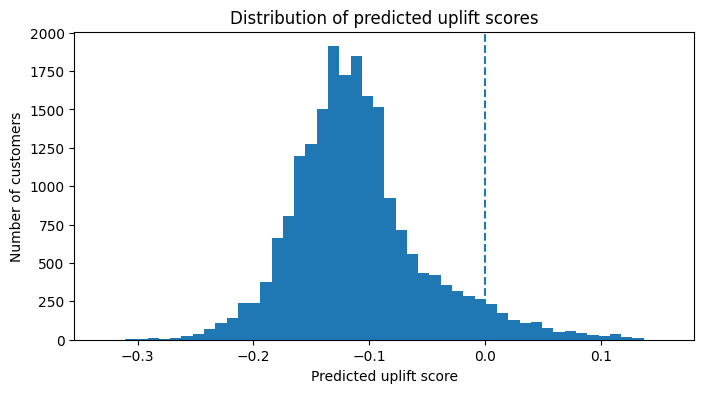

In [705]:
plt.figure(figsize=(8, 4))

plt.hist(df_scored["uplift_score"], bins=50)

plt.axvline(0, linestyle="--")

plt.xlabel("Predicted uplift score")
plt.ylabel("Number of customers")

plt.title("Distribution of predicted uplift scores")
plt.show()

In [706]:
print(y.groupby(t).mean())

treatment
0    0.012791
1    0.010474
Name: cancelations, dtype: float64


## Create randomized experimental groups

In [707]:
# ============================
# Random experimental group assignment
# ============================

df_exp = df_scored.copy()

df_exp = df_exp.sample(frac=1, random_state=42).reset_index(drop=True)

n_a = 7000
n_b = 7000

df_exp["test_group"] = "C_exclude_persuadables"
df_exp.loc[:n_a - 1, "test_group"] = "A_send_all"
df_exp.loc[n_a:n_a + n_b - 1, "test_group"] = "B_exclude_sleeping_dogs"

df_exp["send_email"] = 1

print(df_exp["test_group"].value_counts())
print(
    df_exp.groupby("test_group")["uplift_score"]
    .describe()
)

test_group
A_send_all                 7000
B_exclude_sleeping_dogs    7000
C_exclude_persuadables     6689
Name: count, dtype: int64
                          count      mean       std       min       25%  \
test_group                                                                
A_send_all               7000.0 -0.109381  0.058683 -0.298683 -0.145736   
B_exclude_sleeping_dogs  7000.0 -0.108947  0.058701 -0.330260 -0.145181   
C_exclude_persuadables   6689.0 -0.109333  0.056990 -0.312564 -0.145325   

                              50%       75%       max  
test_group                                             
A_send_all              -0.116716 -0.086108  0.136045  
B_exclude_sleeping_dogs -0.115890 -0.083907  0.156645  
C_exclude_persuadables  -0.115314 -0.084894  0.130440  


## Model-based exclusion strategy for the experimental groups

Two model-based exclusion strategies are applied:

- Group B: exclude customers with the most negative predicted uplift (sleeping dogs)
- Group C: exclude customers with the most positive predicted uplift (persuadables)

The exclusion sizes are fixed in advance in order to satisfy the operational constraint of withholding at most 1,500 emails.

### Apply fixed-size model-based exclusion strategy

In [708]:
# ============================
# Fixed-size exclusion strategy
# ============================

# number of excluded customers
n_sleeping_dogs = 1000
n_persuadables = 500

# initialize
df_exp["send_email"] = 1

# ============================
# Group B: exclude sleeping dogs
# ============================

b_group = (
    df_exp[df_exp["test_group"] == "B_exclude_sleeping_dogs"]
    .sort_values("uplift_score", ascending=True)
)

dogs_ids = b_group.head(n_sleeping_dogs).index

df_exp.loc[dogs_ids, "send_email"] = 0

# ============================
# Group C: exclude persuadables
# ============================

c_group = (
    df_exp[df_exp["test_group"] == "C_exclude_persuadables"]
    .sort_values("uplift_score", ascending=False)
)

persuadables_ids = c_group.head(n_persuadables).index

df_exp.loc[persuadables_ids, "send_email"] = 0

# ============================
# Reports
# ============================

print("Excluded sleeping dogs:", len(dogs_ids))
print("Excluded persuadables:", len(persuadables_ids))

print("\nEmails sent by group:")
print(
    df_exp.groupby("test_group")["send_email"]
    .value_counts()
)

Excluded sleeping dogs: 1000
Excluded persuadables: 500

Emails sent by group:
test_group               send_email
A_send_all               1             7000
B_exclude_sleeping_dogs  1             6000
                         0             1000
C_exclude_persuadables   1             6189
                         0              500
Name: count, dtype: int64


In [709]:
df_exp.head()

,customer_id,uplift_score,test_group,send_email
0,0002244627,-0.153499,A_send_all,1
1,0002508695,-0.116854,A_send_all,1
2,0003089761,-0.149877,A_send_all,1
3,0002280813,-0.123799,A_send_all,1
4,0002125410,-0.091994,A_send_all,1


## Export operational email assignment list

In [710]:
# Export

df_exp[[
    "customer_id",
    "test_group",
    "send_email"
]].to_csv(
    "../models/email_send_list.csv",
    index=False
)

# Verify that the trained T-learner ensemble was saved successfully

print("CSV saved.")

CSV saved.


## Verify balance of uplift-score distributions across randomized groups

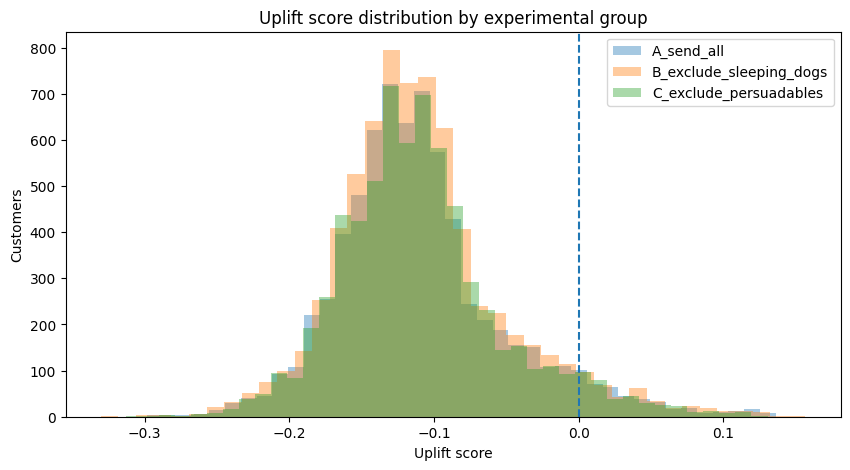

In [711]:
plt.figure(figsize=(10, 5))

for group in df_exp["test_group"].unique():

    g = df_exp[df_exp["test_group"] == group]

    plt.hist(
        g["uplift_score"],
        bins=40,
        alpha=0.4,
        label=group
    )

plt.axvline(0, linestyle="--")

plt.xlabel("Uplift score")
plt.ylabel("Customers")

plt.title("Uplift score distribution by experimental group")

plt.legend()
plt.show()

## Export final operational customer ID lists for email assignment - for Salesforce

In [712]:
df_exp["customer_id"] = (
    df_exp["customer_id"]
    .astype("string")
    .str.zfill(10)
)

# customers who SHOULD receive the email

df_exp.loc[
    df_exp["send_email"] == 1,
    ["customer_id"]
].to_csv(
    "../models/send_email_ids.csv",
    index=False
)

# customers who should NOT receive the email
df_exp.loc[
    df_exp["send_email"] == 0,
    ["customer_id"]
].to_csv(
    "../models/do_not_send_email_ids.csv",
    index=False
)

print("Files saved.")

Files saved.


## Modell "evaluation"

## robustness check

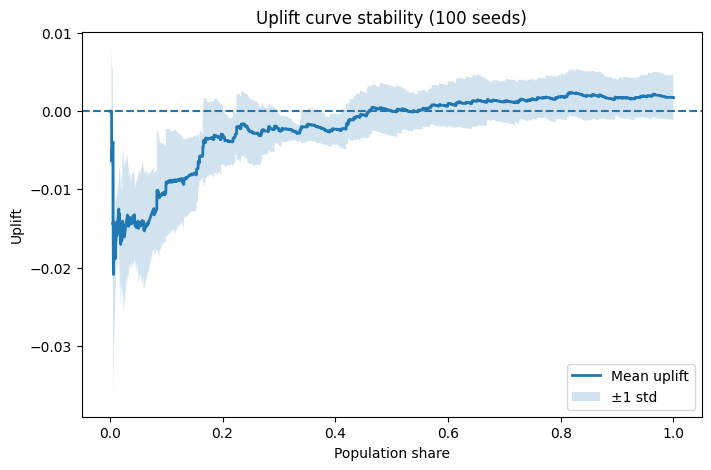

In [713]:
# ============================
# Stability check (mean + variance)
# ============================

import numpy as np
import matplotlib.pyplot as plt

curves = []

for rs in seeds:

    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t,
        test_size=0.3,
        random_state=rs,
        stratify=t
    )

    model_t = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    model_c = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=rs,
        min_samples_leaf=50,
        max_depth=4,
        max_features="sqrt"
    )

    model_t.fit(X_train[t_train == 1], y_train[t_train == 1])
    model_c.fit(X_train[t_train == 0], y_train[t_train == 0])

    uplift = (
        model_c.predict_proba(X_test)[:, 1]
        - model_t.predict_proba(X_test)[:, 1]
    )

    x, curve = uplift_curve(uplift, y_test.values, t_test.values)
    curves.append(curve.values)

curves = np.array(curves)

mean_curve = curves.mean(axis=0)
std_curve = curves.std(axis=0)

plt.figure(figsize=(8, 5))

plt.plot(x, mean_curve, linewidth=2, label="Mean uplift")

plt.fill_between(
    x,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.2,
    label="±1 std"
)

plt.axhline(0, linestyle="--")

plt.title("Uplift curve stability (100 seeds)")
plt.xlabel("Population share")
plt.ylabel("Uplift")
plt.legend()
plt.show()

In [714]:
[col for col in df_features_raw.columns if "end" in col.lower() or "bis" in col.lower() or "künd" in col.lower()]

df_model = df_model.merge(
    df[["customer_id", "cancel_date"]],
    on="customer_id",
    how="left"
)

email_date = pd.Timestamp("2026-03-19")

top = df_test.sort_values("uplift_tlearner").head(500)

# подтягиваем cancel_date по индексу
cancel_dates = df_model.loc[top.index, "cancel_date"]
days = (cancel_dates - email_date).dt.days

days = days[(days >= 0) & (days <= 30)]
days.hist()

NameError: name 'df_test' is not defined

count     5.000000
mean     12.800000
std       7.085196
min       3.000000
25%       9.000000
50%      13.000000
75%      19.000000
max      20.000000
Name: end_date, dtype: float64


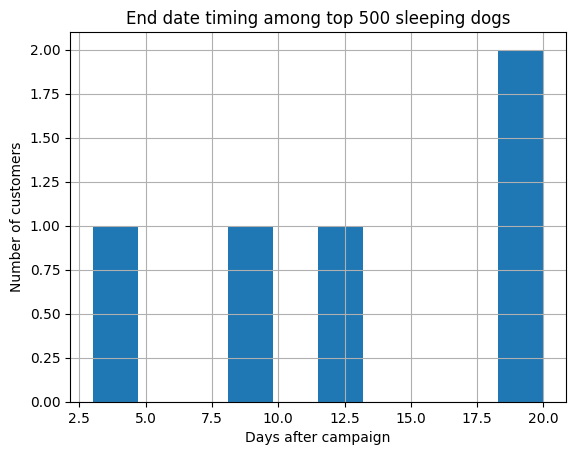

In [ ]:
# clean old end_date columns
df_model = df_model.drop(
    columns=[c for c in df_model.columns if c.startswith("end_date")],
    errors="ignore"
)

# merge end_date once
df_model = df_model.merge(
    df[["customer_id", "end_date"]].drop_duplicates("customer_id"),
    on="customer_id",
    how="left"
)

# make sure datetime
df_model["end_date"] = pd.to_datetime(df_model["end_date"], errors="coerce")

# campaign date
email_date = pd.Timestamp("2026-03-19")

# top 500 sleeping dogs from test set
top = df_test.sort_values("uplift_tlearner", ascending=True).head(500)

# get end_date for same customers
end_dates = df_model.loc[top.index, "end_date"]

# days from campaign to contract end
days = (end_dates - email_date).dt.days

# only churn window: 0–30 days after campaign
days_30 = days[(days >= 0) & (days <= 30)]

print(days_30.describe())

days_30.hist()
plt.xlabel("Days after campaign")
plt.ylabel("Number of customers")
plt.title("End date timing among top 500 sleeping dogs")
plt.show()

In [ ]:
import numpy as np

def uplift_diff(df):
    return (
        df[df.treatment==0]["cancelations"].mean()
        - df[df.treatment==1]["cancelations"].mean()
    )

boot = []
for _ in range(500):
    sample = df_model.sample(frac=1, replace=True)
    boot.append(uplift_diff(sample))

print(np.percentile(boot, [2.5, 97.5]))

[-0.00109144  0.00553979]


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# control
c_success = df_model[df_model.treatment==0]["cancelations"].sum()
c_n = df_model[df_model.treatment==0].shape[0]

# treatment
t_success = df_model[df_model.treatment==1]["cancelations"].sum()
t_n = df_model[df_model.treatment==1].shape[0]

stat, pval = proportions_ztest([c_success, t_success], [c_n, t_n])
print(pval)

0.14688802131867504


### Feature Importance Interpretation

Overall, the difference in important features between treatment and control models indicates the presence of heterogeneous treatment effects, meaning that the impact of the email varies across customer segments.

In [ ]:
import pandas as pd

feat_imp_treat = pd.Series(
    m_treat.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp_ctrl = pd.Series(
    m_ctrl.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("=== TOP features (treatment) ===")
print(feat_imp_treat.head(10))

print("\n=== TOP features (control) ===")
print(feat_imp_ctrl.head(10))

ValueError: Length of values (42) does not match length of index (41)

## Business Interpretation

The results indicate that the email campaign does not affect all customers equally. Instead, its impact varies significantly across customer segments.


- uplift = P(churn | email) − P(churn | no email)

### do NOT write

In [ ]:
df_test = df_test.copy()
df_test["customer_id"] = df_model.loc[df_test.index, "customer_id"]

df_test.sort_values("uplift_tlearner", ascending=False)[
    ["customer_id", "uplift_tlearner"]
].head(10)

,customer_id,uplift_tlearner
7625,0016110428,0.985929
21966,0018887326,0.968836
27942,0019537994,0.966099
14504,0017825356,0.961290
1785,0019611828,0.959326
25199,0019144045,0.955707
23795,0019064072,0.945237
5454,0017039272,0.931901
25529,0019037565,0.924665
13343,0016242120,0.917682


## to write

In [ ]:
df_test.sort_values("uplift_tlearner", ascending=True)[
    ["customer_id", "uplift_tlearner"]
].head(10)

,customer_id,uplift_tlearner
18863,0016551346,-0.980726
23212,0019115519,-0.976191
26501,0019409758,-0.973537
27262,0019470021,-0.973121
9323,0018269086,-0.965636
3645,0018775030,-0.956666
19105,0016582531,-0.951631
18407,0016647866,-0.950564
23188,0019005530,-0.949697
16010,0016481144,-0.932117


auuc

In [ ]:
import numpy as np

def auuc(df_qini):
    return np.trapezoid(df_qini["uplift_curve"], df_qini["perc"])

auuc_t = auuc(qini_t)
auuc_cf = auuc(qini_cf)

print("T-learner:", auuc_t)
print("Causal Forest:", auuc_cf)

KeyError: 'uplift_curve'

## Satistic

## Cancellation Behavior Over Time

This plot shows the daily cancellation request rates (per 1,000 customers) for both treatment (received email) and control (no email) groups within the campaign observation window.

To ensure comparability between groups of different sizes, the counts are normalized per 1,000 customers and smoothed using a 3-day rolling average.

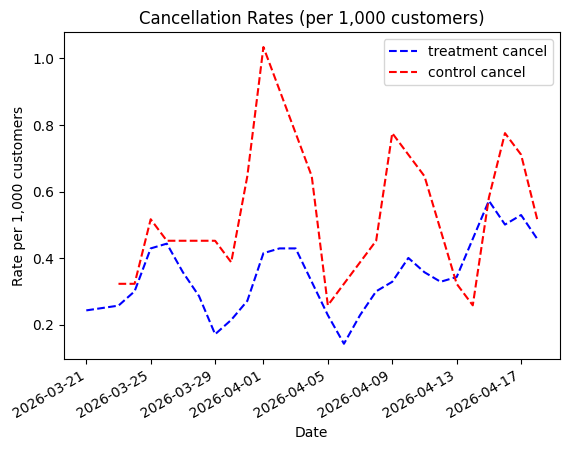

In [ ]:
import matplotlib.pyplot as plt

# window
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-18")

# group sizes
n_treat = (df_model["treatment"] == 1).sum()
n_control = (df_model["treatment"] == 0).sum()


# --- CANCEL DATE ---
df_cancel = df_kuend_clean.merge(
    df_model[["customer_id", "treatment"]],
    on="customer_id",
    how="left"
)

df_cancel["cancel_date"] = pd.to_datetime(
    df_cancel["cancel_date"],
    dayfirst=True,
    errors="coerce"
)

df_cancel = df_cancel[
    (df_cancel["cancel_date"] >= start) &
    (df_cancel["cancel_date"] <= end)
]

treat_cancel = (
    df_cancel[df_cancel["treatment"] == 1]["cancel_date"]
    .value_counts()
    .sort_index()
    .rolling(3).mean()
) / n_treat * 1000

control_cancel = (
    df_cancel[df_cancel["treatment"] == 0]["cancel_date"]
    .value_counts()
    .sort_index()
    .rolling(3).mean()
) / n_control * 1000


# --- PLOT ---
plt.figure()

# cancel (dashed)
treat_cancel.plot(label="treatment cancel", linestyle="--", color="blue")
control_cancel.plot(label="control cancel", linestyle="--", color="red")

plt.title("Cancellation Rates (per 1,000 customers)")
plt.xlabel("Date")
plt.ylabel("Rate per 1,000 customers")
plt.legend()

plt.show()

MÜLL






-
-
-


In [ ]:
df_model.head(5)

,customer_id,treatment,contract_with_device,payment_method,billing_freq,age_bin,gender,milieu,cluster,has_phone,...,email_optout,cancelations,churn,negative_outcome_ch+email,negative_outcome_canc+email,negative_outcome,cancel_date,end_date,email_clicked,email_opened
0,0018640485,0,0,SEPA,M,"(65, 75]",female,PMA,Floh,0,...,0,0,0,0,0,0,NaT,NaT,0,0
1,0018703242,0,0,Invoice,M,"(55, 65]",female,PER,Floh,0,...,0,0,0,0,0,0,NaT,2028-04-13,0,0
2,0019173245,0,0,SEPA,M,"(55, 65]",female,NOK,Floh,0,...,0,0,0,0,0,0,NaT,NaT,0,0
3,0019173659,0,0,SEPA,M,"(75, 100]",male,PER,Seehund,0,...,0,0,0,0,0,0,NaT,NaT,0,0
4,0019173423,0,0,SEPA,M,"(75, 100]",female,EPE,Elefant,0,...,0,0,0,0,0,0,NaT,NaT,0,0


In [ ]:
uplift_test = (
    m_treat.predict_proba(X_test)[:, 1] -
    m_ctrl.predict_proba(X_test)[:, 1]
)

df_test = X_test.copy()
df_test["uplift_tlearner"] = uplift_test
df_test["y"] = y_test
df_test["t"] = t_test

print(df_test["uplift_tlearner"].describe())

count    8538.000000
mean        0.116362
std         0.216856
min        -0.804634
25%        -0.007683
50%         0.047937
75%         0.220906
max         0.925440
Name: uplift_tlearner, dtype: float64


In [ ]:
df_test["decile"] = pd.qcut(df_test["uplift_tlearner"], 10, labels=False)

df_test.groupby("decile")["y"].mean()

decile
0    0.003513
1    0.004684
2    0.005855
3    0.002345
4    0.005855
5    0.012881
6    0.004689
7    0.004684
8    0.009368
9    0.019906
Name: y, dtype: float64

## uplift = P(churn | no email) - P(churn | email)

### do NOT write

In [ ]:
df_test = df_test.copy()
df_test["customer_id"] = df_model.loc[df_test.index, "customer_id"]

df_test.sort_values("uplift_tlearner", ascending=False)[
    ["customer_id", "uplift_tlearner"]
].head(10)

,customer_id,uplift_tlearner
9323,0018269086,0.925440
9806,0018352481,0.902055
15575,0017492641,0.899337
22440,0018267473,0.879099
16679,0018168950,0.865040
26078,0016683081,0.854276
11777,0018888023,0.843137
9918,0018480301,0.839129
8283,0018416168,0.837135
23160,0018800134,0.829329


### write

In [ ]:
df_test.sort_values("uplift_tlearner", ascending=True)[
    ["customer_id", "uplift_tlearner"]
].head(10)

,customer_id,uplift_tlearner
499,0016453648,-0.804634
12196,0016475287,-0.789930
18449,0016662345,-0.776120
22961,0016452170,-0.771156
26570,0019413175,-0.740195
10528,0016548969,-0.738716
10963,0016453824,-0.706093
6111,0016451441,-0.689448
19318,0016652483,-0.682134
3261,0019285647,-0.673781


In [ ]:
# define observation window for post-campaign churn
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-19")

# create churn variable: 1 if subscription ended within the observation window
df["churn"] = (
    df["end_date"].notna() &
    (df["end_date"] >= start) &
    (df["end_date"] <= end)
).astype(int)

# overall churn rate (%)
churn = df["churn"].value_counts()
overall_churn = df["churn"].mean() * 100

# overall churn by treatment group (%)
churn_by_group = df.groupby("treatment")["churn"].mean() * 100
churn_by_group.index = ["Not sent", "Sent"]

# KA churn based on the same base: all customers in each group
ka_churn_by_group = df.groupby("treatment").apply(
    lambda x: ((x["churn"] == 1) & (x["cancel_reason"] == "KA")).mean() * 100
)
ka_churn_by_group.index = ["Not sent", "Sent"]

# share of KA among all churned customers (%)
ka_share_among_churned = (
    (df.loc[df["churn"] == 1, "cancel_reason"] == "KA").mean() * 100
)

# print results
print(f"Overall churn: {churn}\n")
print(f"Overall churn: {overall_churn:.4f}%\n")

print("Overall churn by treatment group (%):")
print(churn_by_group.round(4))

print("\nKA churn by treatment group (% of all customers):")
print(ka_churn_by_group.round(4))

print(f"\nShare of KA among all churned customers: {ka_share_among_churned:.4f}%")

Overall churn: churn
0    28255
1      202
Name: count, dtype: int64

Overall churn: 0.7098%

Overall churn by treatment group (%):
Not sent    0.9690
Sent        0.6524
Name: churn, dtype: float64

KA churn by treatment group (% of all customers):
Not sent    0.1357
Sent        0.2189
dtype: float64

Share of KA among all churned customers: 28.7129%


In [ ]:
# define observation window for post-campaign churn
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-19")

# create churn variable: 1 if subscription ended within the observation window
df["churn"] = (
    df["end_date"].notna() &
    (df["end_date"] >= start) &
    (df["end_date"] <= end)
).astype(int)

# overall churn rate (%)
overall_churn = df["churn"].mean() * 100

# overall churn by treatment group (%)
churn_by_group = df.groupby("treatment")["churn"].mean() * 100
churn_by_group.index = ["Not sent", "Sent"]

# KA churn based on the same base: all customers in each group
ka_churn_by_group = df.groupby("treatment").apply(
    lambda x: ((x["churn"] == 1) & (x["cancel_reason"] == "KA")).mean() * 100
)
ka_churn_by_group.index = ["Not sent", "Sent"]

# share of KA among all churned customers (%)
ka_share_among_churned = (
    (df.loc[df["churn"] == 1, "cancel_reason"] == "KA").mean() * 100
)

# print results
print(f"Overall churn: {overall_churn:.4f}%\n")

print("Overall churn by treatment group (%):")
print(churn_by_group.round(4))

print("\nKA churn by treatment group (% of all customers):")
print(ka_churn_by_group.round(4))

print(f"\nShare of KA among all churned customers: {ka_share_among_churned:.4f}%")

Overall churn: 0.7098%

Overall churn by treatment group (%):
Not sent    0.9690
Sent        0.6524
Name: churn, dtype: float64

KA churn by treatment group (% of all customers):
Not sent    0.1357
Sent        0.2189
dtype: float64

Share of KA among all churned customers: 28.7129%


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Große der Gruppe
n_control = (df["treatment"] == 0).sum()
n_treat = (df["treatment"] == 1).sum()

# Anzahl churn
churn_control = df.loc[df["treatment"] == 0, "churn"].sum()
churn_treat = df.loc[df["treatment"] == 1, "churn"].sum()

# delta
delta = (churn_treat / n_treat) - (churn_control / n_control)

# z-test
stat, pval = proportions_ztest(
    [churn_treat, churn_control],
    [n_treat, n_control]
)

print(f"Delta Kündigungsrate: {delta*100:.4f} pp")
print(f"Z-stat: {stat:.4f}")
print(f"P-value: {pval:.4f}")

Delta Kündigungsrate: -0.3165 pp
Z-stat: -2.4507
P-value: 0.0143


In [ ]:
# define observation window for post-campaign churn
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-19")

# create churn variable: 1 if subscription ended within the observation window
df["churn"] = (
    df["cancel_date"].notna() &
    (df["cancel_date"] >= start) &
    (df["cancel_date"] <= end)
).astype(int)

# overall churn rate (%)
overall_churn = df["churn"].mean() * 100

# overall churn by treatment group (%)
churn_by_group = df.groupby("treatment")["churn"].mean() * 100
churn_by_group.index = ["Not sent", "Sent"]

# KA churn based on the same base: all customers in each group
ka_churn_by_group = df.groupby("treatment").apply(
    lambda x: ((x["churn"] == 1) & (x["cancel_reason"] == "KA")).mean() * 100
)
ka_churn_by_group.index = ["Not sent", "Sent"]

# share of KA among all churned customers (%)
ka_share_among_churned = (
    (df.loc[df["churn"] == 1, "cancel_reason"] == "KA").mean() * 100
)

# print results
print(f"Overall churn: {overall_churn:.4f}%\n")

print("Overall churn by treatment group (%):")
print(churn_by_group.round(4))

print("\nKA churn by treatment group (% of all customers):")
print(ka_churn_by_group.round(4))

print(f"\nShare of KA among all churned customers: {ka_share_among_churned:.4f}%")

Overall churn: 1.1069%

Overall churn by treatment group (%):
Not sent    1.2984
Sent        1.0645
Name: churn, dtype: float64

KA churn by treatment group (% of all customers):
Not sent    0.3682
Sent        0.3305
dtype: float64

Share of KA among all churned customers: 30.4762%


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Große der Gruppe
n_control = (df["treatment"] == 0).sum()
n_treat = (df["treatment"] == 1).sum()

# Anzahl churn
churn_control = df.loc[df["treatment"] == 0, "churn"].sum()
churn_treat = df.loc[df["treatment"] == 1, "churn"].sum()

# delta
delta = (churn_treat / n_treat) - (churn_control / n_control)

# z-test
stat, pval = proportions_ztest(
    [churn_treat, churn_control],
    [n_treat, n_control]
)

print(f"Delta Kündigungsrate: {delta*100:.4f} pp")
print(f"Z-stat: {stat:.4f}")
print(f"P-value: {pval:.4f}")

Delta Kündigungsrate: -0.2339 pp
Z-stat: -1.4532
P-value: 0.1462
